# CSQA Layer-Output And Internal-State Noising Analysis

Perturbational sensitivity notebook for a single model family and a single task.

- model family: Qwen2.5
- target checkpoint: 3B instruct model
- perturbation class: additive Gaussian noise on internal states
- decision space: constrained A-E answer-choice logits only


In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from src.data.load_csqa import load_csqa

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)


/home/ubuntu/Transformer-Decision-Traces/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Global study settings only.


In [2]:
MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
EVAL_SPLIT = "validation"
EVAL_LIMIT = 600
SUMMARY_NOISE_SCALES = [0.25]
DOSE_RESPONSE_SCALES = [0.25]
SEED = 42


## Data And Model Setup


In [3]:
torch.manual_seed(SEED)
np.random.seed(SEED)

LETTERS = ["A", "B", "C", "D", "E"]
MAX_SEQ_LEN = 384
CLEAN_BATCH_SIZE = 4
INTERVENTION_BATCH_SIZE = 2

eval_rows = load_csqa(split=EVAL_SPLIT, limit=EVAL_LIMIT).copy()
eval_rows["n_choices"] = eval_rows["csqa_choices"].map(len)
eval_rows["prompt_len_chars"] = eval_rows["text"].str.len()

if torch.cuda.is_available():
    if torch.cuda.is_bf16_supported():
        model_dtype = torch.bfloat16
    else:
        model_dtype = torch.float16
    device_map = "auto"
else:
    model_dtype = torch.float32
    device_map = None

tok = AutoTokenizer.from_pretrained(MODEL_ID)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token
tok.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=model_dtype,
    device_map=device_map,
    attn_implementation="eager",
)
model.eval()


def build_answer_token_ids(tok):
    out = {}
    for letter in LETTERS:
        ids = tok(" " + letter, add_special_tokens=False)["input_ids"]
        if len(ids) != 1:
            raise ValueError(f"Answer token '{letter}' is not single-token: {ids}")
        out[letter] = int(ids[0])
    return out


answer_token_ids = build_answer_token_ids(tok)
answer_ids = [answer_token_ids[l] for l in LETTERS]
answer_id_tensor = torch.tensor(answer_ids, dtype=torch.long)

display(eval_rows[["example_id", "answerKey", "prompt_len_chars"]].head())
print("eval rows:", len(eval_rows))
print("answer token ids:", answer_token_ids)


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 434/434 [00:00<00:00, 943.41it/s]


,example_id,answerKey,prompt_len_chars
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,187
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,145
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,149
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,141
4,054aade2878f1bd189aa590565583d91,A,158


eval rows: 600
answer token ids: {'A': 362, 'B': 425, 'C': 356, 'D': 422, 'E': 468}


## Helper Functions


In [4]:
def get_final_norm_module(model):
    candidates = [
        "model.norm",
        "model.final_layernorm",
        "transformer.ln_f",
        "gpt_neox.final_layer_norm",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    return None


def get_decoder_layers(model):
    candidates = [
        "model.layers",
        "transformer.h",
        "gpt_neox.layers",
    ]
    for path in candidates:
        cur = model
        ok = True
        for part in path.split("."):
            if not hasattr(cur, part):
                ok = False
                break
            cur = getattr(cur, part)
        if ok:
            return cur
    raise ValueError("Could not locate decoder layers on this model.")


def encode_prompts(texts, tok, max_seq_len):
    batch = tok(
        list(texts),
        add_special_tokens=False,
        truncation=True,
        max_length=max_seq_len,
        padding=True,
        return_tensors="pt",
    )
    pos = []
    for mask in batch["attention_mask"]:
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        pos.append(int(nz[-1].item()))
    batch["decision_pos"] = torch.tensor(pos, dtype=torch.long)
    return batch


def compute_choice_metrics(choice_logits, true_choice_idx):
    predicted_answer_index = choice_logits.argmax(dim=-1)
    row_idx = torch.arange(choice_logits.shape[0], device=choice_logits.device)
    true_logits = choice_logits[row_idx, true_choice_idx]
    other_logits = choice_logits.clone()
    other_logits[row_idx, true_choice_idx] = -torch.inf
    highest_other_logit = other_logits.max(dim=-1).values
    true_answer_vs_best_other_logit_gap = true_logits - highest_other_logit
    return predicted_answer_index.detach().cpu(), true_answer_vs_best_other_logit_gap.detach().cpu()


def apply_token_noise(hidden, decision_pos, noise_scale):
    row_idx = torch.arange(hidden.shape[0], device=hidden.device)
    token_hidden = hidden[row_idx, decision_pos]
    rms = token_hidden.float().pow(2).mean(dim=-1, keepdim=True).sqrt().to(token_hidden.dtype)
    noise = torch.randn_like(token_hidden) * (noise_scale * rms)
    hidden_out = hidden.clone()
    hidden_out[row_idx, decision_pos] = token_hidden + noise
    return hidden_out


def resolve_token_positions(attention_mask, decision_pos):
    first_prompt_pos = []
    middle_prompt_pos = []
    pre_decision_pos = []

    for mask, decision_idx in zip(attention_mask, decision_pos):
        nz = torch.nonzero(mask, as_tuple=False).view(-1)
        first_prompt_pos.append(int(nz[0].item()))
        middle_prompt_pos.append(int(nz[len(nz) // 2].item()))
        if len(nz) >= 2:
            pre_decision_pos.append(int(nz[-2].item()))
        else:
            pre_decision_pos.append(int(decision_idx.item()))

    return {
        "decision": decision_pos.clone(),
        "first_prompt": torch.tensor(first_prompt_pos, dtype=torch.long),
        "middle_prompt": torch.tensor(middle_prompt_pos, dtype=torch.long),
        "pre_decision": torch.tensor(pre_decision_pos, dtype=torch.long),
    }


def paired_permutation_pvalue(x, y, n_permutations=2000, seed=SEED):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    diff = x[valid] - y[valid]
    if diff.size == 0:
        return np.nan

    observed = float(np.abs(diff.mean()))
    rng = np.random.default_rng(int(seed))
    signs = rng.choice(np.array([-1.0, 1.0]), size=(n_permutations, diff.size))
    permuted = np.abs((signs * diff.reshape(1, -1)).mean(axis=1))
    return float((np.sum(permuted >= observed) + 1) / (n_permutations + 1))


def intervention_summary(df, group_cols):
    summary_all = (
        df.groupby(group_cols)
        .agg(
            mean_delta_true_answer_vs_best_other_logit_gap=("delta_true_answer_vs_best_other_logit_gap", "mean"),
            prediction_preservation_rate=("prediction_preserved", "mean"),
            noised_accuracy=("noised_is_correct", "mean"),
        )
    )

    summary_clean_correct = (
        df.loc[df["clean_is_correct"]]
        .groupby(group_cols)
        .agg(
            clean_correct_break_rate=("clean_correct_broken", "mean"),
            noised_accuracy_on_clean_correct=("noised_is_correct", "mean"),
        )
    )

    return summary_all.join(summary_clean_correct, how="left").reset_index()


def aggregate_summary_across_noise_scales(summary_df, group_cols):
    metric_cols = [
        "mean_delta_true_answer_vs_best_other_logit_gap",
        "prediction_preservation_rate",
        "noised_accuracy",
        "clean_correct_break_rate",
        "noised_accuracy_on_clean_correct",
    ]
    agg_spec = {}
    for metric in metric_cols:
        agg_spec[metric + "_mean"] = (metric, "mean")
        agg_spec[metric + "_std"] = (metric, "std")

    return (
        summary_df.groupby(group_cols)
        .agg(**agg_spec)
        .reset_index()
        .fillna(0.0)
    )


def standardize_series(values):
    values = np.asarray(values, dtype=float)
    mean = float(np.mean(values))
    std = float(np.std(values))
    if std <= 0:
        return np.zeros_like(values, dtype=float)
    return (values - mean) / std


decoder_layers = get_decoder_layers(model)
final_norm = get_final_norm_module(model)
L = len(decoder_layers)
answer_ids_on_device = answer_id_tensor.to(model.lm_head.weight.device)
log_answer_choice_count = float(np.log(len(LETTERS)))

substep_display_names = {
    "pre_attn": "Pre-attention residual state",
    "post_attn": "Post-attention residual state",
    "post_mlp": "Post-feed-forward residual state",
}

component_display_names = {
    "attention_output": "Attention output",
    "feed_forward_output": "Feed-forward output",
}

probe_cpu = encode_prompts(eval_rows["text"].head(1), tok, MAX_SEQ_LEN)
probe_pos = int(probe_cpu["decision_pos"][0].item())
probe = {k: v.to(model.device) for k, v in probe_cpu.items() if k != "decision_pos"}
with torch.no_grad():
    probe_out = model(**probe, output_hidden_states=True, return_dict=True, use_cache=False)

hidden_probe = probe_out.hidden_states
L_plus_1 = len(hidden_probe)
raw_last = hidden_probe[-1][0, probe_pos].float()
target_choice_logits = probe_out.logits[0, probe_pos, answer_ids_on_device].float().detach().cpu()
raw_choice_logits = torch.mv(model.lm_head.weight[answer_ids_on_device].float().detach().cpu(), raw_last.detach().cpu())

if final_norm is not None:
    normed_last = final_norm(raw_last.unsqueeze(0)).squeeze(0)
    normed_choice_logits = torch.mv(model.lm_head.weight[answer_ids_on_device].float().detach().cpu(), normed_last.detach().cpu())
    raw_err = torch.mean(torch.abs(raw_choice_logits - target_choice_logits)).item()
    normed_err = torch.mean(torch.abs(normed_choice_logits - target_choice_logits)).item()
    LAST_LAYER_NEEDS_NORM = bool(normed_err < raw_err)
else:
    LAST_LAYER_NEEDS_NORM = False


def maybe_apply_final_norm_gpu(h, layer_idx):
    if final_norm is None:
        return h
    if layer_idx < L:
        return final_norm(h)
    if LAST_LAYER_NEEDS_NORM:
        return final_norm(h)
    return h


print("decoder layers:", L)


decoder layers: 36


### Decision Score Used In All Summaries

	rue_answer_vs_best_other_logit_gap means:

- logit of the true answer choice
- minus the highest logit among the remaining A-E choices

Negative change means the true answer became less competitive.


## Clean Baseline

Final answer-choice outputs without intervention.


In [5]:
def extract_clean_baseline(frame):
    rows = []

    for start in tqdm(range(0, len(frame), CLEAN_BATCH_SIZE), total=int(math.ceil(len(frame) / CLEAN_BATCH_SIZE)), desc="clean baseline"):
        batch_df = frame.iloc[start:start + CLEAN_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)
        true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

        with torch.no_grad():
            out = model(**batch, return_dict=True, use_cache=False)

        row_idx = torch.arange(len(batch_df), device=decision_pos.device)
        final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
        predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(final_logits, true_choice_idx)
        clean_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

        for bi in range(len(batch_df)):
            rows.append(
                {
                    "example_id": batch_df.loc[bi, "example_id"],
                    "true_choice_idx": int(true_choice_idx[bi].item()),
                    "clean_prediction_idx": int(predicted_answer_index[bi].item()),
                    "clean_prediction": LETTERS[int(predicted_answer_index[bi].item())],
                    "clean_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[bi].item()),
                    "clean_is_correct": bool(clean_is_correct[bi].item()),
                }
            )

    return pd.DataFrame(rows)


clean_df = extract_clean_baseline(eval_rows)
analysis_df = eval_rows.merge(clean_df, on="example_id", how="left", validate="one_to_one")

display(
    analysis_df[["example_id", "answerKey", "clean_prediction", "clean_true_answer_vs_best_other_logit_gap", "clean_is_correct"]].head()
)
print("clean accuracy:", round(float(analysis_df["clean_is_correct"].mean()), 4))


clean baseline: 100%|██████████| 150/150 [00:07<00:00, 21.34it/s]


,example_id,answerKey,clean_prediction,clean_true_answer_vs_best_other_logit_gap,clean_is_correct
0,701fac8b8c04ab56c4394b2e7b2aa8df,A,D,-1.500,False
1,1db37ef1b4ebdcbc12a7d7dec87472a8,A,A,9.625,True
2,a5cb28d53c4cd35c06fbbbb3dbf6aaa8,B,B,10.625,True
3,ce6c00c4f3edcd54ab4fa1e3a8582e7c,A,A,14.000,True
4,054aade2878f1bd189aa590565583d91,A,D,-8.125,False


clean accuracy: 0.79


## Layer-Output Noising

Noise is injected at the output of one decoder layer at a time. Only the decision-position token is modified.


In [6]:
def run_layer_output_noising_scan(frame, noise_scale, desc):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc=desc):
        torch.manual_seed(SEED + target_layer)
        current_state = {}

        def noise_hook(module, args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
            if isinstance(output, tuple):
                return (hidden_out,) + output[1:]
            return hidden_out

        handle = decoder_layers[target_layer].register_forward_hook(noise_hook)

        try:
            for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                decision_pos = batch_cpu.pop("decision_pos")
                batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                decision_pos = decision_pos.to(model.device)
                true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                current_state["decision_pos"] = decision_pos

                with torch.no_grad():
                    out = model(**batch, return_dict=True, use_cache=False)

                row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(final_logits, true_choice_idx)
                noised_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

                for bi in range(len(batch_df)):
                    rows.append(
                        {
                            "example_id": batch_df.loc[bi, "example_id"],
                            "target_layer": int(target_layer),
                            "noise_scale": float(noise_scale),
                            "noised_prediction_idx": int(predicted_answer_index[bi].item()),
                            "noised_prediction": LETTERS[int(predicted_answer_index[bi].item())],
                            "noised_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[bi].item()),
                            "noised_is_correct": bool(noised_is_correct[bi].item()),
                        }
                    )
        finally:
            handle.remove()

    return pd.DataFrame(rows)

layer_output_parts = []
for noise_scale in DOSE_RESPONSE_SCALES:
    part = run_layer_output_noising_scan(
        eval_rows,
        noise_scale,
        f"layer-output noising scale={noise_scale}",
    )
    part["noise_scale"] = float(noise_scale)
    layer_output_parts.append(part)

layer_output_df_all = pd.concat(layer_output_parts, ignore_index=True)
layer_output_df_all = layer_output_df_all.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_true_answer_vs_best_other_logit_gap", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
layer_output_df_all["prediction_preserved"] = layer_output_df_all["noised_prediction_idx"].eq(layer_output_df_all["clean_prediction_idx"])
layer_output_df_all["delta_true_answer_vs_best_other_logit_gap"] = layer_output_df_all["noised_true_answer_vs_best_other_logit_gap"] - layer_output_df_all["clean_true_answer_vs_best_other_logit_gap"]
layer_output_df_all["clean_correct_broken"] = layer_output_df_all["clean_is_correct"] & (~layer_output_df_all["noised_is_correct"])

layer_output_df = layer_output_df_all.loc[layer_output_df_all["noise_scale"].isin(SUMMARY_NOISE_SCALES)].copy()
layer_output_summary_by_scale = intervention_summary(layer_output_df, ["noise_scale", "target_layer"])
layer_output_summary_by_scale["layer_index_1based"] = layer_output_summary_by_scale["target_layer"] + 1
layer_output_summary = aggregate_summary_across_noise_scales(layer_output_summary_by_scale, ["target_layer", "layer_index_1based"])

display(layer_output_summary_by_scale.round(4))
display(layer_output_summary.round(4))


layer-output noising scale=0.25: 100%|██████████| 36/36 [07:09<00:00, 11.94s/it]


,noise_scale,target_layer,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.25,0,-0.1779,0.9633,0.7833,0.0232,0.9768,1
1,0.25,1,-0.1054,0.9600,0.7817,0.0253,0.9747,2
2,0.25,2,-0.0673,0.9683,0.7950,0.0127,0.9873,3
3,0.25,3,-0.0492,0.9667,0.7950,0.0127,0.9873,4
4,0.25,4,-0.0492,0.9650,0.7850,0.0232,0.9768,5
5,0.25,5,-0.0775,0.9717,0.7900,0.0127,0.9873,6
6,0.25,6,-0.0602,0.9617,0.7867,0.0211,0.9789,7
7,0.25,7,-0.0700,0.9650,0.7883,0.0190,0.9810,8
8,0.25,8,0.0529,0.9767,0.7950,0.0084,0.9916,9
9,0.25,9,-0.0017,0.9700,0.7883,0.0169,0.9831,10


,target_layer,layer_index_1based,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,noised_accuracy_std,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean,noised_accuracy_on_clean_correct_std
0,0,1,-0.1779,0.0,0.9633,0.0,0.7833,0.0,0.0232,0.0,0.9768,0.0
1,1,2,-0.1054,0.0,0.9600,0.0,0.7817,0.0,0.0253,0.0,0.9747,0.0
2,2,3,-0.0673,0.0,0.9683,0.0,0.7950,0.0,0.0127,0.0,0.9873,0.0
3,3,4,-0.0492,0.0,0.9667,0.0,0.7950,0.0,0.0127,0.0,0.9873,0.0
4,4,5,-0.0492,0.0,0.9650,0.0,0.7850,0.0,0.0232,0.0,0.9768,0.0
5,5,6,-0.0775,0.0,0.9717,0.0,0.7900,0.0,0.0127,0.0,0.9873,0.0
6,6,7,-0.0602,0.0,0.9617,0.0,0.7867,0.0,0.0211,0.0,0.9789,0.0
7,7,8,-0.0700,0.0,0.9650,0.0,0.7883,0.0,0.0190,0.0,0.9810,0.0
8,8,9,0.0529,0.0,0.9767,0.0,0.7950,0.0,0.0084,0.0,0.9916,0.0
9,9,10,-0.0017,0.0,0.9700,0.0,0.7883,0.0,0.0169,0.0,0.9831,0.0


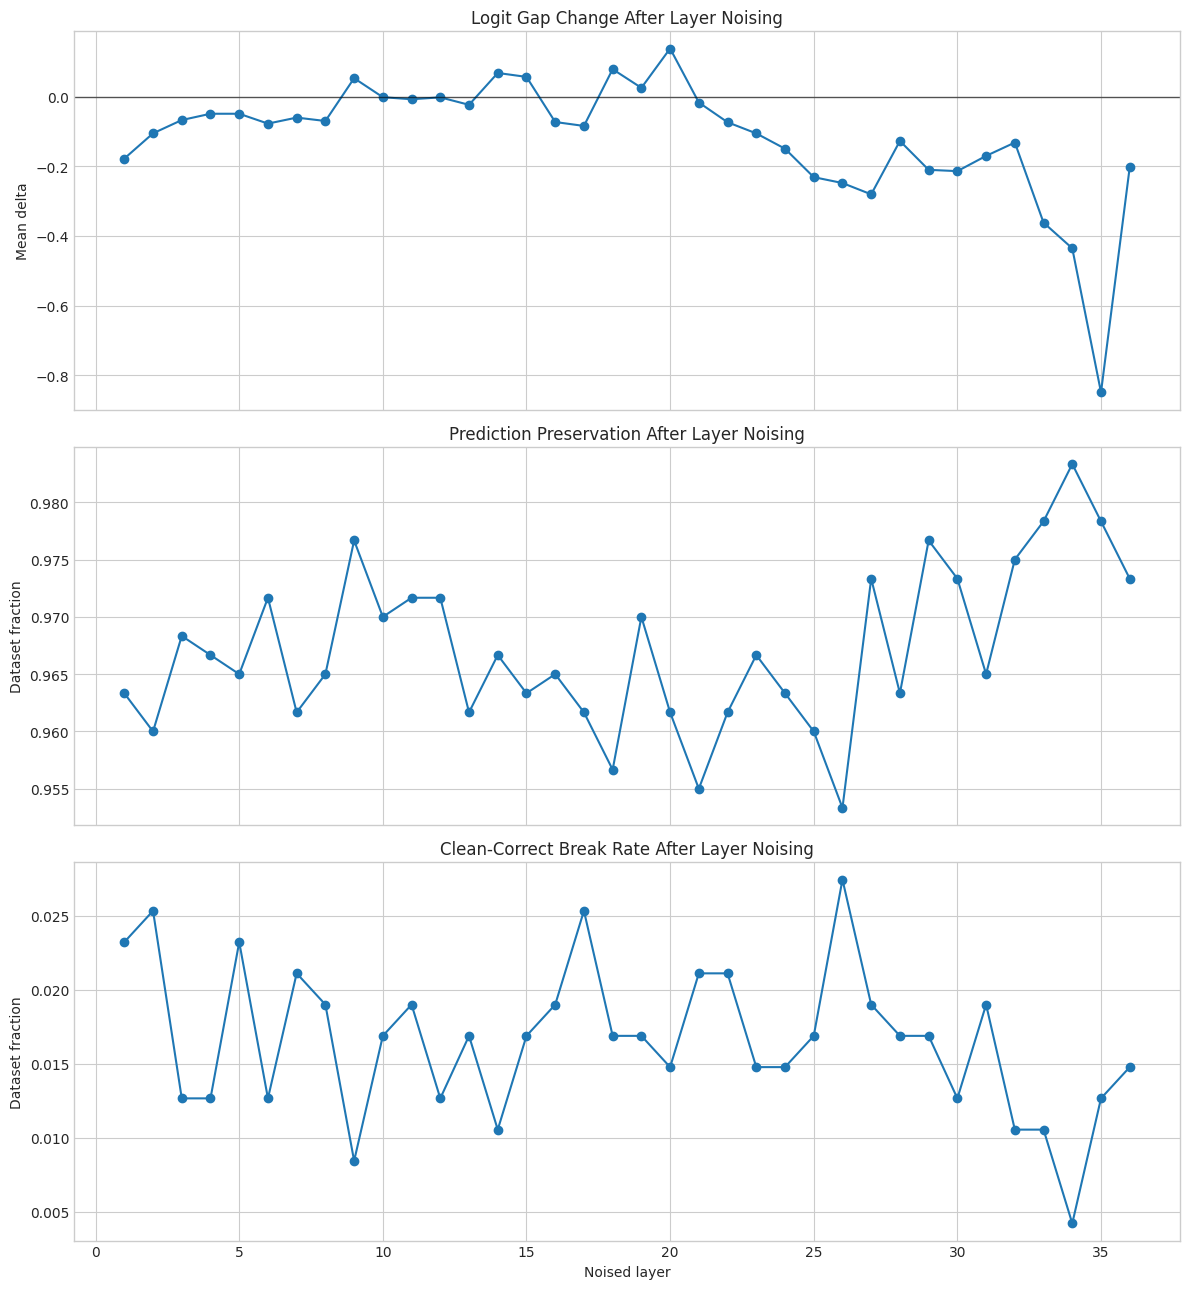

In [7]:
layers_1based = layer_output_summary["layer_index_1based"].to_numpy()

fig, axes = plt.subplots(3, 1, figsize=(12, 13), sharex=True)

axes[0].plot(layers_1based, layer_output_summary["mean_delta_true_answer_vs_best_other_logit_gap_mean"], marker="o")
axes[0].fill_between(
    layers_1based,
    layer_output_summary["mean_delta_true_answer_vs_best_other_logit_gap_mean"] - layer_output_summary["mean_delta_true_answer_vs_best_other_logit_gap_std"],
    layer_output_summary["mean_delta_true_answer_vs_best_other_logit_gap_mean"] + layer_output_summary["mean_delta_true_answer_vs_best_other_logit_gap_std"],
    alpha=0.2,
)
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Logit Gap Change After Layer Noising")

axes[1].plot(layers_1based, layer_output_summary["prediction_preservation_rate_mean"], marker="o")
axes[1].fill_between(
    layers_1based,
    layer_output_summary["prediction_preservation_rate_mean"] - layer_output_summary["prediction_preservation_rate_std"],
    layer_output_summary["prediction_preservation_rate_mean"] + layer_output_summary["prediction_preservation_rate_std"],
    alpha=0.2,
)
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Prediction Preservation After Layer Noising")

axes[2].plot(layers_1based, layer_output_summary["clean_correct_break_rate_mean"], marker="o")
axes[2].fill_between(
    layers_1based,
    layer_output_summary["clean_correct_break_rate_mean"] - layer_output_summary["clean_correct_break_rate_std"],
    layer_output_summary["clean_correct_break_rate_mean"] + layer_output_summary["clean_correct_break_rate_std"],
    alpha=0.2,
)
axes[2].set_xlabel("Noised layer")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-Correct Break Rate After Layer Noising")

plt.tight_layout()
plt.show()


In [8]:
display(
    layer_output_summary.sort_values(
        ["clean_correct_break_rate_mean", "mean_delta_true_answer_vs_best_other_logit_gap_mean"],
        ascending=[False, True],
    )[[
        "layer_index_1based",
        "mean_delta_true_answer_vs_best_other_logit_gap_mean",
        "mean_delta_true_answer_vs_best_other_logit_gap_std",
        "prediction_preservation_rate_mean",
        "prediction_preservation_rate_std",
        "noised_accuracy_mean",
        "clean_correct_break_rate_mean",
        "clean_correct_break_rate_std",
        "noised_accuracy_on_clean_correct_mean",
    ]]
    .head(10)
    .round(4)
)


,layer_index_1based,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean
25,26,-0.2481,0.0,0.9533,0.0,0.7800,0.0274,0.0,0.9726
1,2,-0.1054,0.0,0.9600,0.0,0.7817,0.0253,0.0,0.9747
16,17,-0.0842,0.0,0.9617,0.0,0.7800,0.0253,0.0,0.9747
0,1,-0.1779,0.0,0.9633,0.0,0.7833,0.0232,0.0,0.9768
4,5,-0.0492,0.0,0.9650,0.0,0.7850,0.0232,0.0,0.9768
21,22,-0.0735,0.0,0.9617,0.0,0.7883,0.0211,0.0,0.9789
6,7,-0.0602,0.0,0.9617,0.0,0.7867,0.0211,0.0,0.9789
20,21,-0.0169,0.0,0.9550,0.0,0.7850,0.0211,0.0,0.9789
26,27,-0.2806,0.0,0.9733,0.0,0.7817,0.0190,0.0,0.9810
30,31,-0.1702,0.0,0.9650,0.0,0.7900,0.0190,0.0,0.9810


### Decision-Position Specificity Test

Gaussian noising is used here as a perturbational stress test. The comparison below checks whether the answer-producing token state is more fragile than control prompt positions under the same layer-output corruption.


In [9]:
position_noise_scale = float(SUMMARY_NOISE_SCALES[0])
position_labels = ["decision", "first_prompt", "middle_prompt", "pre_decision"]
position_label_display = {
    "decision": "Decision position",
    "first_prompt": "First prompt token",
    "middle_prompt": "Middle prompt token",
    "pre_decision": "Token before decision",
}


def run_layer_output_position_noising_scan(frame, noise_scale, position_labels, desc):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc=desc):
        for position_idx, target_position in enumerate(position_labels):
            torch.manual_seed(SEED + 1000 * (target_layer + 1) + position_idx)
            current_state = {}

            def noise_hook(module, args, output):
                hidden = output[0] if isinstance(output, tuple) else output
                hidden_out = apply_token_noise(hidden, current_state["target_pos"], noise_scale)
                if isinstance(output, tuple):
                    return (hidden_out,) + output[1:]
                return hidden_out

            handle = decoder_layers[target_layer].register_forward_hook(noise_hook)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    target_positions = resolve_token_positions(batch_cpu["attention_mask"], decision_pos)
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    target_pos = target_positions[target_position].to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["target_pos"] = target_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_position": target_position,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(predicted_answer_index[bi].item()),
                                "noised_prediction": LETTERS[int(predicted_answer_index[bi].item())],
                                "noised_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


position_noising_df = run_layer_output_position_noising_scan(
    eval_rows,
    position_noise_scale,
    position_labels,
    desc=f"position specificity, scale={position_noise_scale}",
)
position_noising_df = position_noising_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_true_answer_vs_best_other_logit_gap", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
position_noising_df["prediction_preserved"] = position_noising_df["noised_prediction_idx"].eq(position_noising_df["clean_prediction_idx"])
position_noising_df["delta_true_answer_vs_best_other_logit_gap"] = position_noising_df["noised_true_answer_vs_best_other_logit_gap"] - position_noising_df["clean_true_answer_vs_best_other_logit_gap"]
position_noising_df["clean_correct_broken"] = position_noising_df["clean_is_correct"] & (~position_noising_df["noised_is_correct"])

position_summary = intervention_summary(position_noising_df, ["target_layer", "target_position"])
position_summary["layer_index_1based"] = position_summary["target_layer"] + 1
position_summary["target_position_label"] = position_summary["target_position"].map(position_label_display)

display(position_summary.head(16).round(4))


position specificity, scale=0.25: 100%|██████████| 36/36 [28:49<00:00, 48.05s/it]


,target_layer,target_position,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based,target_position_label
0,0,decision,-0.0804,0.9717,0.7917,0.0127,0.9873,1,Decision position
1,0,first_prompt,0.0085,0.9800,0.7850,0.0127,0.9873,1,First prompt token
2,0,middle_prompt,0.0250,0.9817,0.7900,0.0084,0.9916,1,Middle prompt token
3,0,pre_decision,-0.0360,0.9833,0.7917,0.0084,0.9916,1,Token before decision
4,1,decision,-0.1360,0.9650,0.7900,0.0169,0.9831,2,Decision position
5,1,first_prompt,0.0906,0.9717,0.7900,0.0148,0.9852,2,First prompt token
6,1,middle_prompt,-0.0227,0.9817,0.7900,0.0084,0.9916,2,Middle prompt token
7,1,pre_decision,-0.0323,0.9783,0.7867,0.0127,0.9873,2,Token before decision
8,2,decision,-0.0808,0.9683,0.7950,0.0084,0.9916,3,Decision position
9,2,first_prompt,-1.0999,0.8467,0.7633,0.0970,0.9030,3,First prompt token


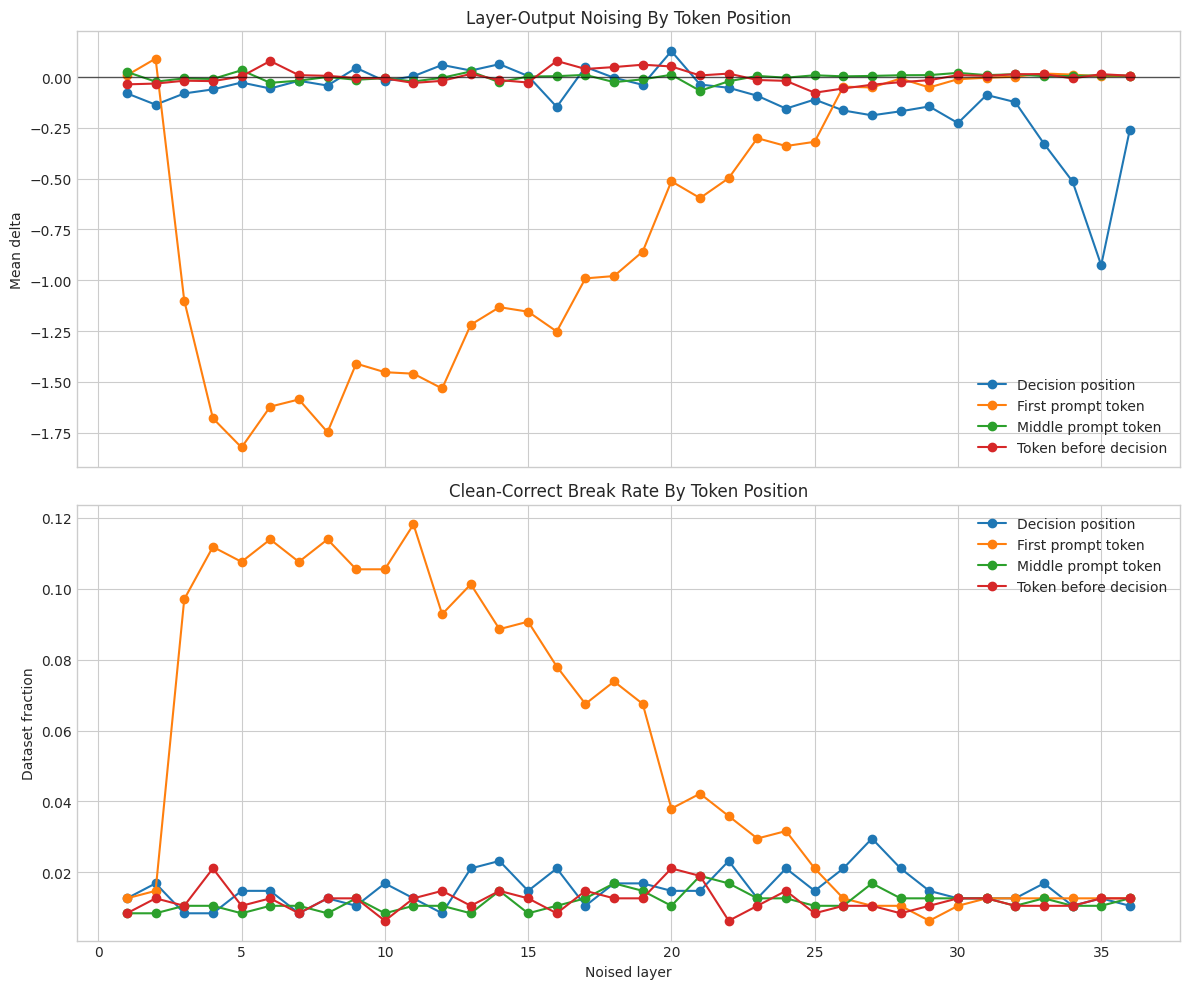

In [10]:
position_order = ["decision", "first_prompt", "middle_prompt", "pre_decision"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for position_name in position_order:
    part = position_summary.loc[position_summary["target_position"].eq(position_name)].sort_values("layer_index_1based")
    x = part["layer_index_1based"].to_numpy()
    label = position_label_display[position_name]
    axes[0].plot(x, part["mean_delta_true_answer_vs_best_other_logit_gap"], marker="o", label=label)
    axes[1].plot(x, part["clean_correct_break_rate"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Layer-Output Noising By Token Position")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-Correct Break Rate By Token Position")
axes[1].legend()

plt.tight_layout()
plt.show()


In [11]:
decision_part = (
    position_noising_df.loc[position_noising_df["target_position"].eq("decision")]
    [["example_id", "target_layer", "clean_is_correct", "delta_true_answer_vs_best_other_logit_gap", "clean_correct_broken"]]
    .rename(
        columns={
            "delta_true_answer_vs_best_other_logit_gap": "decision_delta_true_answer_vs_best_other_logit_gap",
            "clean_correct_broken": "decision_clean_correct_broken",
        }
    )
)

control_mean_part = (
    position_noising_df.loc[~position_noising_df["target_position"].eq("decision")]
    .groupby(["example_id", "target_layer"])
    .agg(
        control_mean_delta_true_answer_vs_best_other_logit_gap=("delta_true_answer_vs_best_other_logit_gap", "mean"),
        control_mean_clean_correct_broken=("clean_correct_broken", "mean"),
    )
    .reset_index()
)

position_specificity_pairs = decision_part.merge(
    control_mean_part,
    on=["example_id", "target_layer"],
    how="inner",
    validate="one_to_one",
)
position_specificity_pairs["extra_logit_gap_damage_at_decision"] = (
    position_specificity_pairs["control_mean_delta_true_answer_vs_best_other_logit_gap"]
    - position_specificity_pairs["decision_delta_true_answer_vs_best_other_logit_gap"]
)
position_specificity_pairs["extra_clean_correct_break_at_decision"] = (
    position_specificity_pairs["decision_clean_correct_broken"].astype(float)
    - position_specificity_pairs["control_mean_clean_correct_broken"]
)

specificity_rows = []
for layer_idx, part in position_specificity_pairs.groupby("target_layer"):
    clean_correct_part = part.loc[part["clean_is_correct"]].copy()
    specificity_rows.append(
        {
            "layer_index_1based": int(layer_idx + 1),
            "mean_extra_logit_gap_damage_at_decision": float(part["extra_logit_gap_damage_at_decision"].mean()),
            "mean_extra_clean_correct_break_at_decision": float(clean_correct_part["extra_clean_correct_break_at_decision"].mean()) if len(clean_correct_part) else np.nan,
            "paired_permutation_pvalue_logit_gap_damage": paired_permutation_pvalue(
                part["control_mean_delta_true_answer_vs_best_other_logit_gap"],
                part["decision_delta_true_answer_vs_best_other_logit_gap"],
                seed=SEED + int(layer_idx),
            ),
            "paired_permutation_pvalue_clean_correct_break": paired_permutation_pvalue(
                clean_correct_part["decision_clean_correct_broken"].astype(float),
                clean_correct_part["control_mean_clean_correct_broken"],
                seed=SEED + 500 + int(layer_idx),
            ),
            "n_pairs": int(len(part)),
            "n_clean_correct_pairs": int(len(clean_correct_part)),
        }
    )

clean_correct_specificity_pairs = position_specificity_pairs.loc[position_specificity_pairs["clean_is_correct"]].copy()
specificity_rows.append(
    {
        "layer_index_1based": "All layers",
        "mean_extra_logit_gap_damage_at_decision": float(position_specificity_pairs["extra_logit_gap_damage_at_decision"].mean()),
        "mean_extra_clean_correct_break_at_decision": float(clean_correct_specificity_pairs["extra_clean_correct_break_at_decision"].mean()),
        "paired_permutation_pvalue_logit_gap_damage": paired_permutation_pvalue(
            position_specificity_pairs["control_mean_delta_true_answer_vs_best_other_logit_gap"],
            position_specificity_pairs["decision_delta_true_answer_vs_best_other_logit_gap"],
            seed=SEED + 999,
        ),
        "paired_permutation_pvalue_clean_correct_break": paired_permutation_pvalue(
            clean_correct_specificity_pairs["decision_clean_correct_broken"].astype(float),
            clean_correct_specificity_pairs["control_mean_clean_correct_broken"],
            seed=SEED + 1499,
        ),
        "n_pairs": int(len(position_specificity_pairs)),
        "n_clean_correct_pairs": int(len(clean_correct_specificity_pairs)),
    }
)

position_specificity_test_df = pd.DataFrame(specificity_rows)
display(position_specificity_test_df.round(4))


,layer_index_1based,mean_extra_logit_gap_damage_at_decision,mean_extra_clean_correct_break_at_decision,paired_permutation_pvalue_logit_gap_damage,paired_permutation_pvalue_clean_correct_break,n_pairs,n_clean_correct_pairs
0,1,0.0796,0.0028,0.0385,0.2959,600,474
1,2,0.1479,0.0049,0.0030,0.2679,600,474
2,3,-0.2941,-0.0309,0.0005,0.0005,600,474
3,4,-0.5089,-0.0394,0.0005,0.0005,600,474
4,5,-0.5685,-0.0274,0.0005,0.0005,600,474
5,6,-0.4674,-0.0309,0.0005,0.0005,600,474
6,7,-0.5133,-0.0338,0.0005,0.0005,600,474
7,8,-0.5384,-0.0323,0.0005,0.0005,600,474
8,9,-0.5210,-0.0331,0.0005,0.0005,600,474
9,10,-0.4683,-0.0232,0.0005,0.0005,600,474


## Substep Noising

Noise is injected at one internal residual-state checkpoint at a time.

- pre-attention residual state
- post-attention residual state
- post-feed-forward residual state


In [12]:
def run_substep_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="substep noising"):
        for substep_idx, target_substep in enumerate(["pre_attn", "post_attn", "post_mlp"]):
            torch.manual_seed(SEED + 1000 * (target_layer + 1) + substep_idx)
            current_state = {}

            if target_substep == "pre_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                handle = decoder_layers[target_layer].register_forward_pre_hook(hook_fn)

            elif target_substep == "post_attn":
                def hook_fn(module, args):
                    hidden = args[0]
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    return (hidden_out,) + args[1:]

                if not hasattr(decoder_layers[target_layer], "post_attention_layernorm"):
                    raise ValueError("Expected post_attention_layernorm on decoder layer.")
                handle = decoder_layers[target_layer].post_attention_layernorm.register_forward_pre_hook(hook_fn)

            else:
                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = decoder_layers[target_layer].register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_substep": target_substep,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(predicted_answer_index[bi].item()),
                                "noised_prediction": LETTERS[int(predicted_answer_index[bi].item())],
                                "noised_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


substep_parts = []
for noise_scale in SUMMARY_NOISE_SCALES:
    part = run_substep_noising_scan(eval_rows, noise_scale)
    part["noise_scale"] = float(noise_scale)
    substep_parts.append(part)

substep_df = pd.concat(substep_parts, ignore_index=True)
substep_df = substep_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_true_answer_vs_best_other_logit_gap", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
substep_df["prediction_preserved"] = substep_df["noised_prediction_idx"].eq(substep_df["clean_prediction_idx"])
substep_df["delta_true_answer_vs_best_other_logit_gap"] = substep_df["noised_true_answer_vs_best_other_logit_gap"] - substep_df["clean_true_answer_vs_best_other_logit_gap"]
substep_df["clean_correct_broken"] = substep_df["clean_is_correct"] & (~substep_df["noised_is_correct"])

substep_summary_by_scale = intervention_summary(substep_df, ["noise_scale", "target_layer", "target_substep"])
substep_summary_by_scale["layer_index_1based"] = substep_summary_by_scale["target_layer"] + 1
substep_summary = aggregate_summary_across_noise_scales(substep_summary_by_scale, ["target_layer", "target_substep", "layer_index_1based"])
substep_summary["target_substep_label"] = substep_summary["target_substep"].map(substep_display_names)

display(substep_summary_by_scale.head(12).round(4))
display(substep_summary.head(12).round(4))


substep noising: 100%|██████████| 36/36 [21:33<00:00, 35.93s/it]


,noise_scale,target_layer,target_substep,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.25,0,post_attn,-0.1442,0.9667,0.7900,0.0169,0.9831,1
1,0.25,0,post_mlp,-0.1240,0.9650,0.7883,0.0169,0.9831,1
2,0.25,0,pre_attn,0.1573,0.9767,0.7917,0.0105,0.9895,1
3,0.25,1,post_attn,-0.0973,0.9733,0.7867,0.0148,0.9852,2
4,0.25,1,post_mlp,-0.0854,0.9683,0.7883,0.0169,0.9831,2
5,0.25,1,pre_attn,-0.1554,0.9667,0.7917,0.0148,0.9852,2
6,0.25,2,post_attn,0.0312,0.9800,0.7917,0.0084,0.9916,3
7,0.25,2,post_mlp,-0.1248,0.9683,0.7950,0.0127,0.9873,3
8,0.25,2,pre_attn,-0.0598,0.9650,0.7917,0.0127,0.9873,3
9,0.25,3,post_attn,-0.0756,0.9750,0.7833,0.0169,0.9831,4


,target_layer,target_substep,layer_index_1based,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,noised_accuracy_std,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean,noised_accuracy_on_clean_correct_std,target_substep_label
0,0,post_attn,1,-0.1442,0.0,0.9667,0.0,0.7900,0.0,0.0169,0.0,0.9831,0.0,Post-attention residual state
1,0,post_mlp,1,-0.1240,0.0,0.9650,0.0,0.7883,0.0,0.0169,0.0,0.9831,0.0,Post-feed-forward residual state
2,0,pre_attn,1,0.1573,0.0,0.9767,0.0,0.7917,0.0,0.0105,0.0,0.9895,0.0,Pre-attention residual state
3,1,post_attn,2,-0.0973,0.0,0.9733,0.0,0.7867,0.0,0.0148,0.0,0.9852,0.0,Post-attention residual state
4,1,post_mlp,2,-0.0854,0.0,0.9683,0.0,0.7883,0.0,0.0169,0.0,0.9831,0.0,Post-feed-forward residual state
5,1,pre_attn,2,-0.1554,0.0,0.9667,0.0,0.7917,0.0,0.0148,0.0,0.9852,0.0,Pre-attention residual state
6,2,post_attn,3,0.0312,0.0,0.9800,0.0,0.7917,0.0,0.0084,0.0,0.9916,0.0,Post-attention residual state
7,2,post_mlp,3,-0.1248,0.0,0.9683,0.0,0.7950,0.0,0.0127,0.0,0.9873,0.0,Post-feed-forward residual state
8,2,pre_attn,3,-0.0598,0.0,0.9650,0.0,0.7917,0.0,0.0127,0.0,0.9873,0.0,Pre-attention residual state
9,3,post_attn,4,-0.0756,0.0,0.9750,0.0,0.7833,0.0,0.0169,0.0,0.9831,0.0,Post-attention residual state


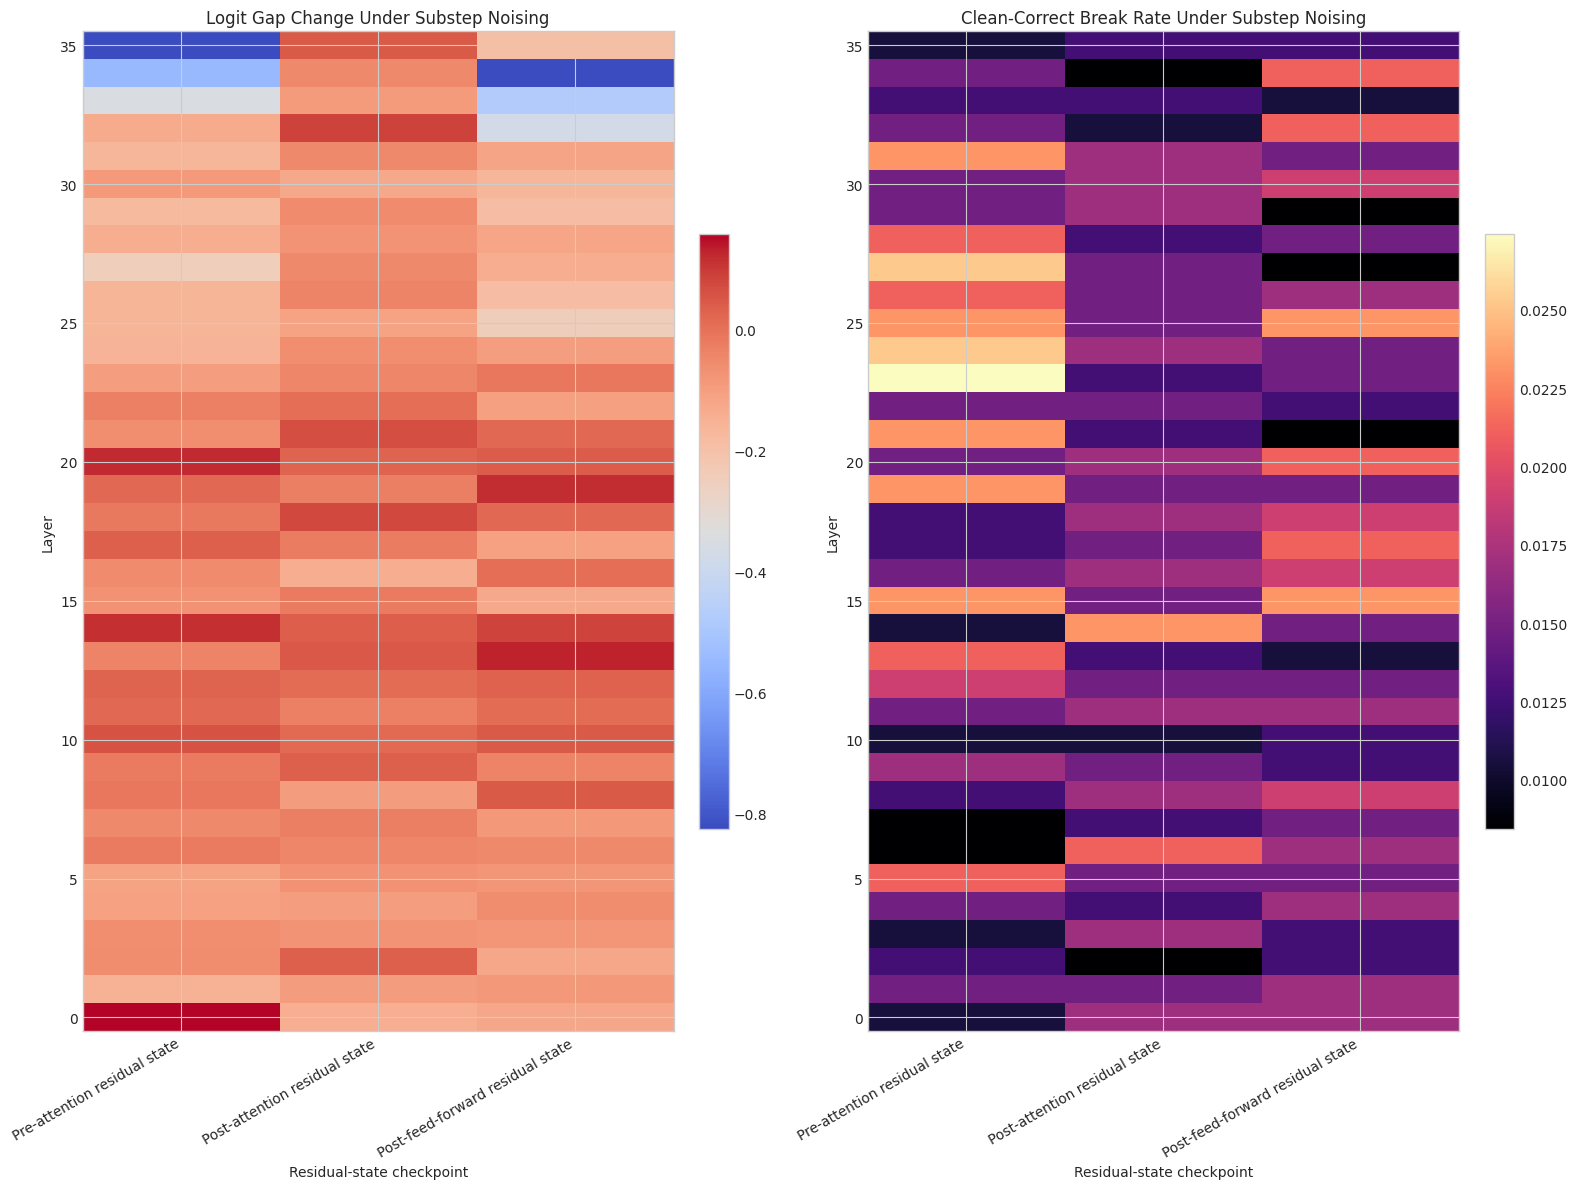

In [13]:
substep_order = ["pre_attn", "post_attn", "post_mlp"]
substep_labels = [substep_display_names[s] for s in substep_order]

def pivot_substep_metric(metric_name):
    table = (
        substep_summary.pivot(index="layer_index_1based", columns="target_substep", values=metric_name)
        .reindex(columns=substep_order)
        .sort_index()
    )
    return table


margin_delta_heat = pivot_substep_metric("mean_delta_true_answer_vs_best_other_logit_gap_mean")
break_rate_heat = pivot_substep_metric("clean_correct_break_rate_mean")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(margin_delta_heat.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Logit Gap Change Under Substep Noising")
axes[0].set_xlabel("Residual-state checkpoint")
axes[0].set_ylabel("Layer")
axes[0].set_xticks(np.arange(len(substep_labels)))
axes[0].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(break_rate_heat.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-Correct Break Rate Under Substep Noising")
axes[1].set_xlabel("Residual-state checkpoint")
axes[1].set_ylabel("Layer")
axes[1].set_xticks(np.arange(len(substep_labels)))
axes[1].set_xticklabels(substep_labels, rotation=30, ha="right")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


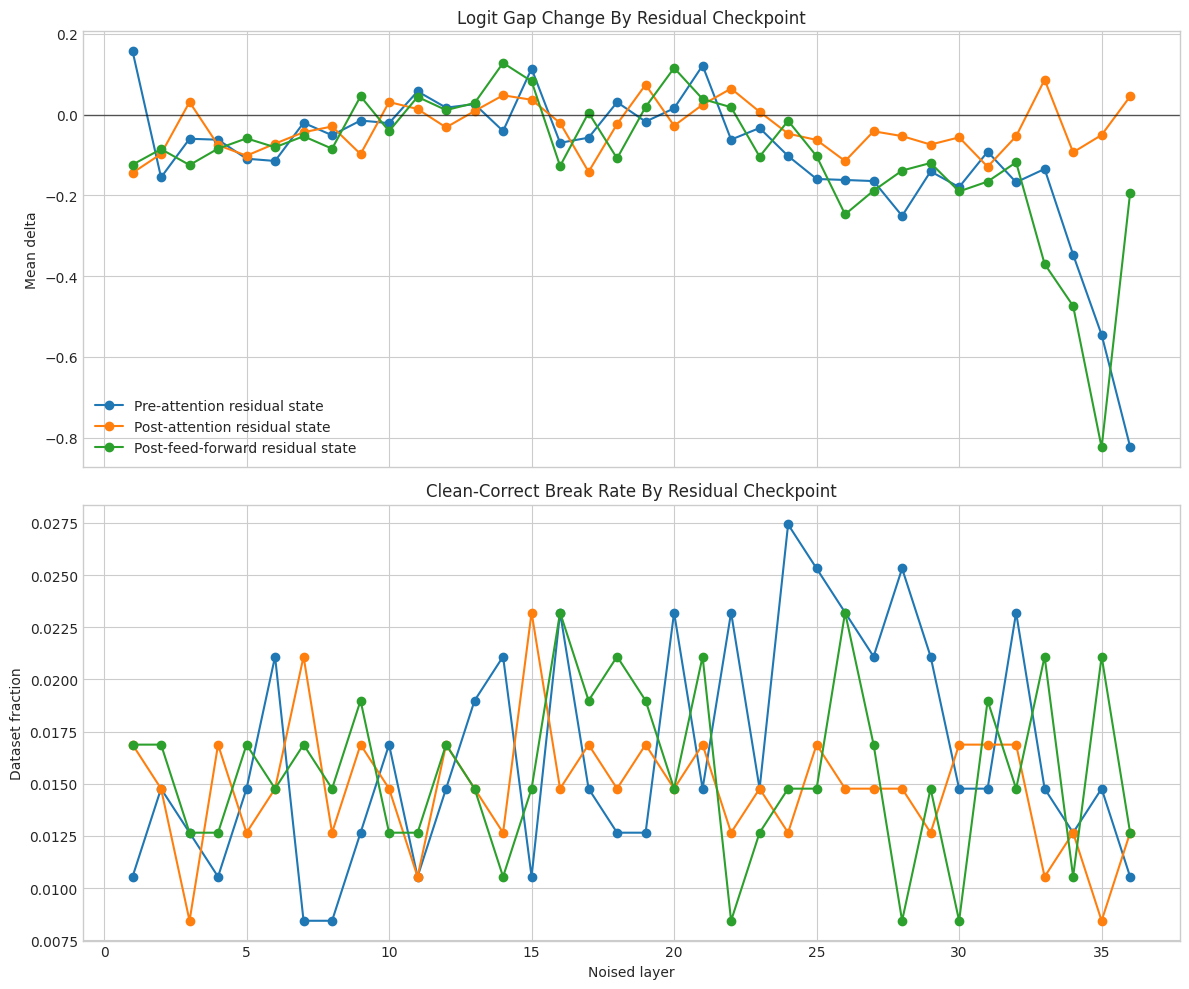

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for substep in substep_order:
    part = substep_summary.loc[substep_summary["target_substep"].eq(substep)].sort_values("layer_index_1based")
    label = substep_display_names[substep]
    x = part["layer_index_1based"].to_numpy()
    axes[0].plot(x, part["mean_delta_true_answer_vs_best_other_logit_gap_mean"], marker="o", label=label)
    axes[0].fill_between(
        x,
        part["mean_delta_true_answer_vs_best_other_logit_gap_mean"] - part["mean_delta_true_answer_vs_best_other_logit_gap_std"],
        part["mean_delta_true_answer_vs_best_other_logit_gap_mean"] + part["mean_delta_true_answer_vs_best_other_logit_gap_std"],
        alpha=0.2,
    )
    axes[1].plot(x, part["clean_correct_break_rate_mean"], marker="o", label=label)
    axes[1].fill_between(
        x,
        part["clean_correct_break_rate_mean"] - part["clean_correct_break_rate_std"],
        part["clean_correct_break_rate_mean"] + part["clean_correct_break_rate_std"],
        alpha=0.2,
    )

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Logit Gap Change By Residual Checkpoint")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-Correct Break Rate By Residual Checkpoint")

plt.tight_layout()
plt.show()


## Component Noising

Noise is injected into the output of one block component at a time.

- attention output
- feed-forward output


In [15]:
def run_component_noising_scan(frame, noise_scale):
    rows = []

    for target_layer in tqdm(range(L), total=L, desc="component noising"):
        for component_idx, target_component in enumerate(["attention_output", "feed_forward_output"]):
            torch.manual_seed(SEED + 10000 * (target_layer + 1) + component_idx)
            current_state = {}
            layer = decoder_layers[target_layer]

            if target_component == "attention_output":
                if not hasattr(layer, "self_attn"):
                    raise ValueError("Expected self_attn on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.self_attn.register_forward_hook(hook_fn)

            else:
                if not hasattr(layer, "mlp"):
                    raise ValueError("Expected mlp on decoder layer.")

                def hook_fn(module, args, output):
                    hidden = output[0] if isinstance(output, tuple) else output
                    hidden_out = apply_token_noise(hidden, current_state["decision_pos"], noise_scale)
                    if isinstance(output, tuple):
                        return (hidden_out,) + output[1:]
                    return hidden_out

                handle = layer.mlp.register_forward_hook(hook_fn)

            try:
                for start in range(0, len(frame), INTERVENTION_BATCH_SIZE):
                    batch_df = frame.iloc[start:start + INTERVENTION_BATCH_SIZE].reset_index(drop=True)
                    batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
                    decision_pos = batch_cpu.pop("decision_pos")
                    batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
                    decision_pos = decision_pos.to(model.device)
                    true_choice_idx = torch.tensor([LETTERS.index(str(x)) for x in batch_df["answerKey"].tolist()], dtype=torch.long, device=model.device)

                    current_state["decision_pos"] = decision_pos

                    with torch.no_grad():
                        out = model(**batch, return_dict=True, use_cache=False)

                    row_idx = torch.arange(len(batch_df), device=decision_pos.device)
                    final_logits = out.logits[row_idx, decision_pos][:, answer_ids_on_device].float()
                    predicted_answer_index, true_answer_vs_best_other_logit_gap = compute_choice_metrics(final_logits, true_choice_idx)
                    noised_is_correct = predicted_answer_index.eq(true_choice_idx.detach().cpu())

                    for bi in range(len(batch_df)):
                        rows.append(
                            {
                                "example_id": batch_df.loc[bi, "example_id"],
                                "target_layer": int(target_layer),
                                "target_component": target_component,
                                "noise_scale": float(noise_scale),
                                "noised_prediction_idx": int(predicted_answer_index[bi].item()),
                                "noised_prediction": LETTERS[int(predicted_answer_index[bi].item())],
                                "noised_true_answer_vs_best_other_logit_gap": float(true_answer_vs_best_other_logit_gap[bi].item()),
                                "noised_is_correct": bool(noised_is_correct[bi].item()),
                            }
                        )
            finally:
                handle.remove()

    return pd.DataFrame(rows)


component_parts = []
for noise_scale in SUMMARY_NOISE_SCALES:
    part = run_component_noising_scan(eval_rows, noise_scale)
    part["noise_scale"] = float(noise_scale)
    component_parts.append(part)

component_df = pd.concat(component_parts, ignore_index=True)
component_df = component_df.merge(
    analysis_df[["example_id", "clean_prediction_idx", "clean_true_answer_vs_best_other_logit_gap", "clean_is_correct"]],
    on="example_id",
    how="left",
    validate="many_to_one",
)
component_df["prediction_preserved"] = component_df["noised_prediction_idx"].eq(component_df["clean_prediction_idx"])
component_df["delta_true_answer_vs_best_other_logit_gap"] = component_df["noised_true_answer_vs_best_other_logit_gap"] - component_df["clean_true_answer_vs_best_other_logit_gap"]
component_df["clean_correct_broken"] = component_df["clean_is_correct"] & (~component_df["noised_is_correct"])

component_summary_by_scale = intervention_summary(component_df, ["noise_scale", "target_layer", "target_component"])
component_summary_by_scale["layer_index_1based"] = component_summary_by_scale["target_layer"] + 1
component_summary = aggregate_summary_across_noise_scales(component_summary_by_scale, ["target_layer", "target_component", "layer_index_1based"])
component_summary["target_component_label"] = component_summary["target_component"].map(component_display_names)

display(component_summary_by_scale.head(12).round(4))
display(component_summary.head(12).round(4))


component noising: 100%|██████████| 36/36 [14:23<00:00, 23.98s/it]


,noise_scale,target_layer,target_component,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.25,0,attention_output,-0.1115,0.9650,0.7900,0.0169,0.9831,1
1,0.25,0,feed_forward_output,-0.0738,0.9733,0.7817,0.0190,0.9810,1
2,0.25,1,attention_output,-0.0308,0.9783,0.7867,0.0127,0.9873,2
3,0.25,1,feed_forward_output,0.0067,0.9817,0.7917,0.0084,0.9916,2
4,0.25,2,attention_output,0.0125,0.9767,0.7867,0.0148,0.9852,3
5,0.25,2,feed_forward_output,-0.0115,0.9750,0.7883,0.0148,0.9852,3
6,0.25,3,attention_output,-0.0300,0.9783,0.7917,0.0105,0.9895,4
7,0.25,3,feed_forward_output,0.0121,0.9800,0.7900,0.0105,0.9895,4
8,0.25,4,attention_output,0.0119,0.9750,0.7917,0.0127,0.9873,5
9,0.25,4,feed_forward_output,0.0229,0.9817,0.7900,0.0105,0.9895,5


,target_layer,target_component,layer_index_1based,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,noised_accuracy_std,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean,noised_accuracy_on_clean_correct_std,target_component_label
0,0,attention_output,1,-0.1115,0.0,0.9650,0.0,0.7900,0.0,0.0169,0.0,0.9831,0.0,Attention output
1,0,feed_forward_output,1,-0.0738,0.0,0.9733,0.0,0.7817,0.0,0.0190,0.0,0.9810,0.0,Feed-forward output
2,1,attention_output,2,-0.0308,0.0,0.9783,0.0,0.7867,0.0,0.0127,0.0,0.9873,0.0,Attention output
3,1,feed_forward_output,2,0.0067,0.0,0.9817,0.0,0.7917,0.0,0.0084,0.0,0.9916,0.0,Feed-forward output
4,2,attention_output,3,0.0125,0.0,0.9767,0.0,0.7867,0.0,0.0148,0.0,0.9852,0.0,Attention output
5,2,feed_forward_output,3,-0.0115,0.0,0.9750,0.0,0.7883,0.0,0.0148,0.0,0.9852,0.0,Feed-forward output
6,3,attention_output,4,-0.0300,0.0,0.9783,0.0,0.7917,0.0,0.0105,0.0,0.9895,0.0,Attention output
7,3,feed_forward_output,4,0.0121,0.0,0.9800,0.0,0.7900,0.0,0.0105,0.0,0.9895,0.0,Feed-forward output
8,4,attention_output,5,0.0119,0.0,0.9750,0.0,0.7917,0.0,0.0127,0.0,0.9873,0.0,Attention output
9,4,feed_forward_output,5,0.0229,0.0,0.9817,0.0,0.7900,0.0,0.0105,0.0,0.9895,0.0,Feed-forward output


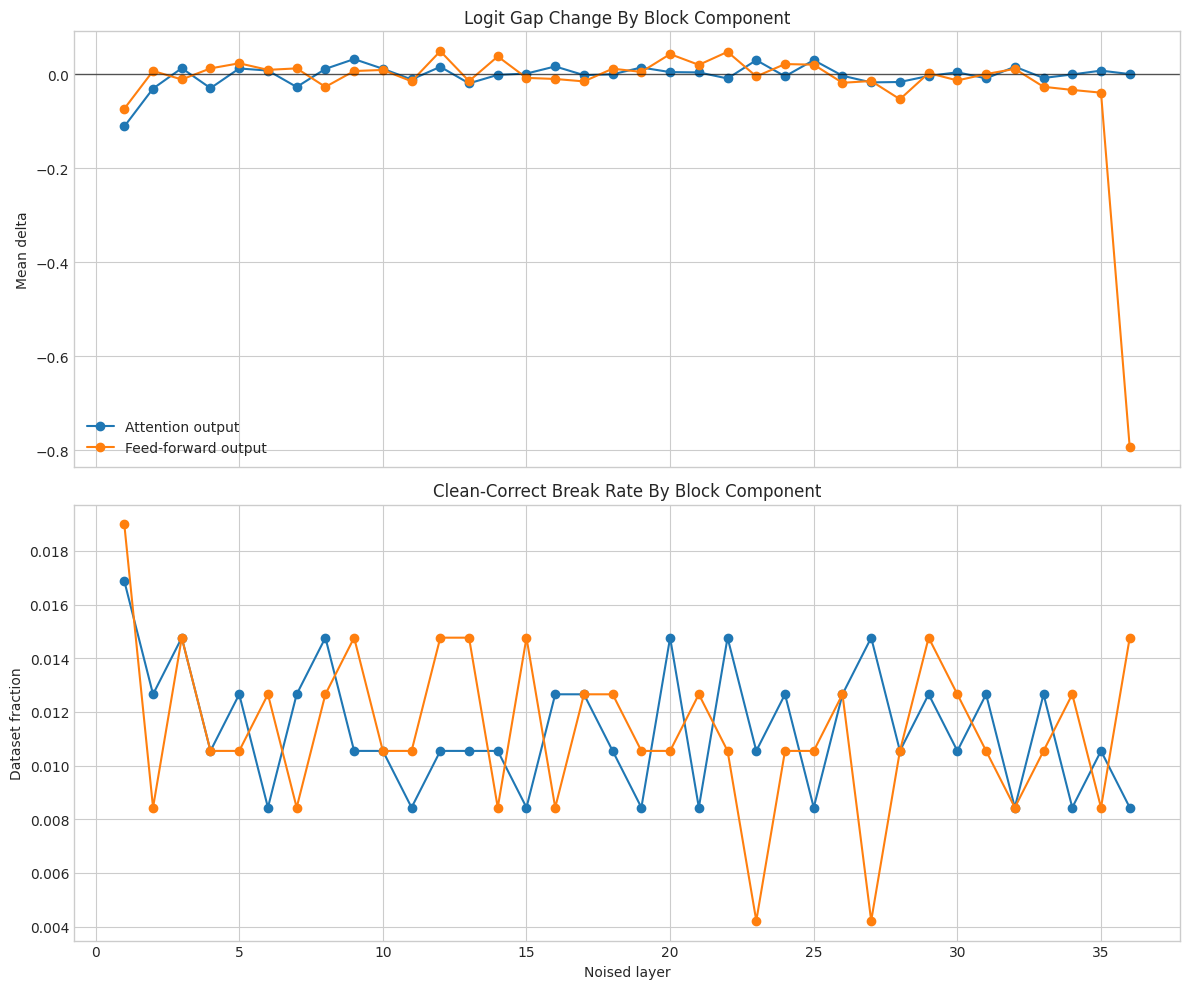

In [16]:
component_order = ["attention_output", "feed_forward_output"]

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for component in component_order:
    part = component_summary.loc[component_summary["target_component"].eq(component)].sort_values("layer_index_1based")
    label = component_display_names[component]
    x = part["layer_index_1based"].to_numpy()
    axes[0].plot(x, part["mean_delta_true_answer_vs_best_other_logit_gap_mean"], marker="o", label=label)
    axes[0].fill_between(
        x,
        part["mean_delta_true_answer_vs_best_other_logit_gap_mean"] - part["mean_delta_true_answer_vs_best_other_logit_gap_std"],
        part["mean_delta_true_answer_vs_best_other_logit_gap_mean"] + part["mean_delta_true_answer_vs_best_other_logit_gap_std"],
        alpha=0.2,
    )
    axes[1].plot(x, part["clean_correct_break_rate_mean"], marker="o", label=label)
    axes[1].fill_between(
        x,
        part["clean_correct_break_rate_mean"] - part["clean_correct_break_rate_std"],
        part["clean_correct_break_rate_mean"] + part["clean_correct_break_rate_std"],
        alpha=0.2,
    )

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Logit Gap Change By Block Component")
axes[0].legend()

axes[1].set_xlabel("Noised layer")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-Correct Break Rate By Block Component")

plt.tight_layout()
plt.show()


In [17]:
component_average = (
    component_summary.groupby("target_component_label")[
        ["mean_delta_true_answer_vs_best_other_logit_gap_mean", "clean_correct_break_rate_mean", "prediction_preservation_rate_mean"]
    ]
    .mean()
    .reset_index()
)

display(component_average.round(4))


,target_component_label,mean_delta_true_answer_vs_best_other_logit_gap_mean,clean_correct_break_rate_mean,prediction_preservation_rate_mean
0,Attention output,-0.0023,0.0114,0.9780
1,Feed-forward output,-0.0231,0.0114,0.9769


## Dose-Response

Repeated layer-output noising scans over multiple noise scales.


In [18]:
dose_response_df = layer_output_df_all.copy()
dose_response_summary = intervention_summary(dose_response_df, ["noise_scale", "target_layer"])
dose_response_summary["layer_index_1based"] = dose_response_summary["target_layer"] + 1

display(dose_response_summary.head(12).round(4))


,noise_scale,target_layer,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct,layer_index_1based
0,0.25,0,-0.1779,0.9633,0.7833,0.0232,0.9768,1
1,0.25,1,-0.1054,0.9600,0.7817,0.0253,0.9747,2
2,0.25,2,-0.0673,0.9683,0.7950,0.0127,0.9873,3
3,0.25,3,-0.0492,0.9667,0.7950,0.0127,0.9873,4
4,0.25,4,-0.0492,0.9650,0.7850,0.0232,0.9768,5
5,0.25,5,-0.0775,0.9717,0.7900,0.0127,0.9873,6
6,0.25,6,-0.0602,0.9617,0.7867,0.0211,0.9789,7
7,0.25,7,-0.0700,0.9650,0.7883,0.0190,0.9810,8
8,0.25,8,0.0529,0.9767,0.7950,0.0084,0.9916,9
9,0.25,9,-0.0017,0.9700,0.7883,0.0169,0.9831,10


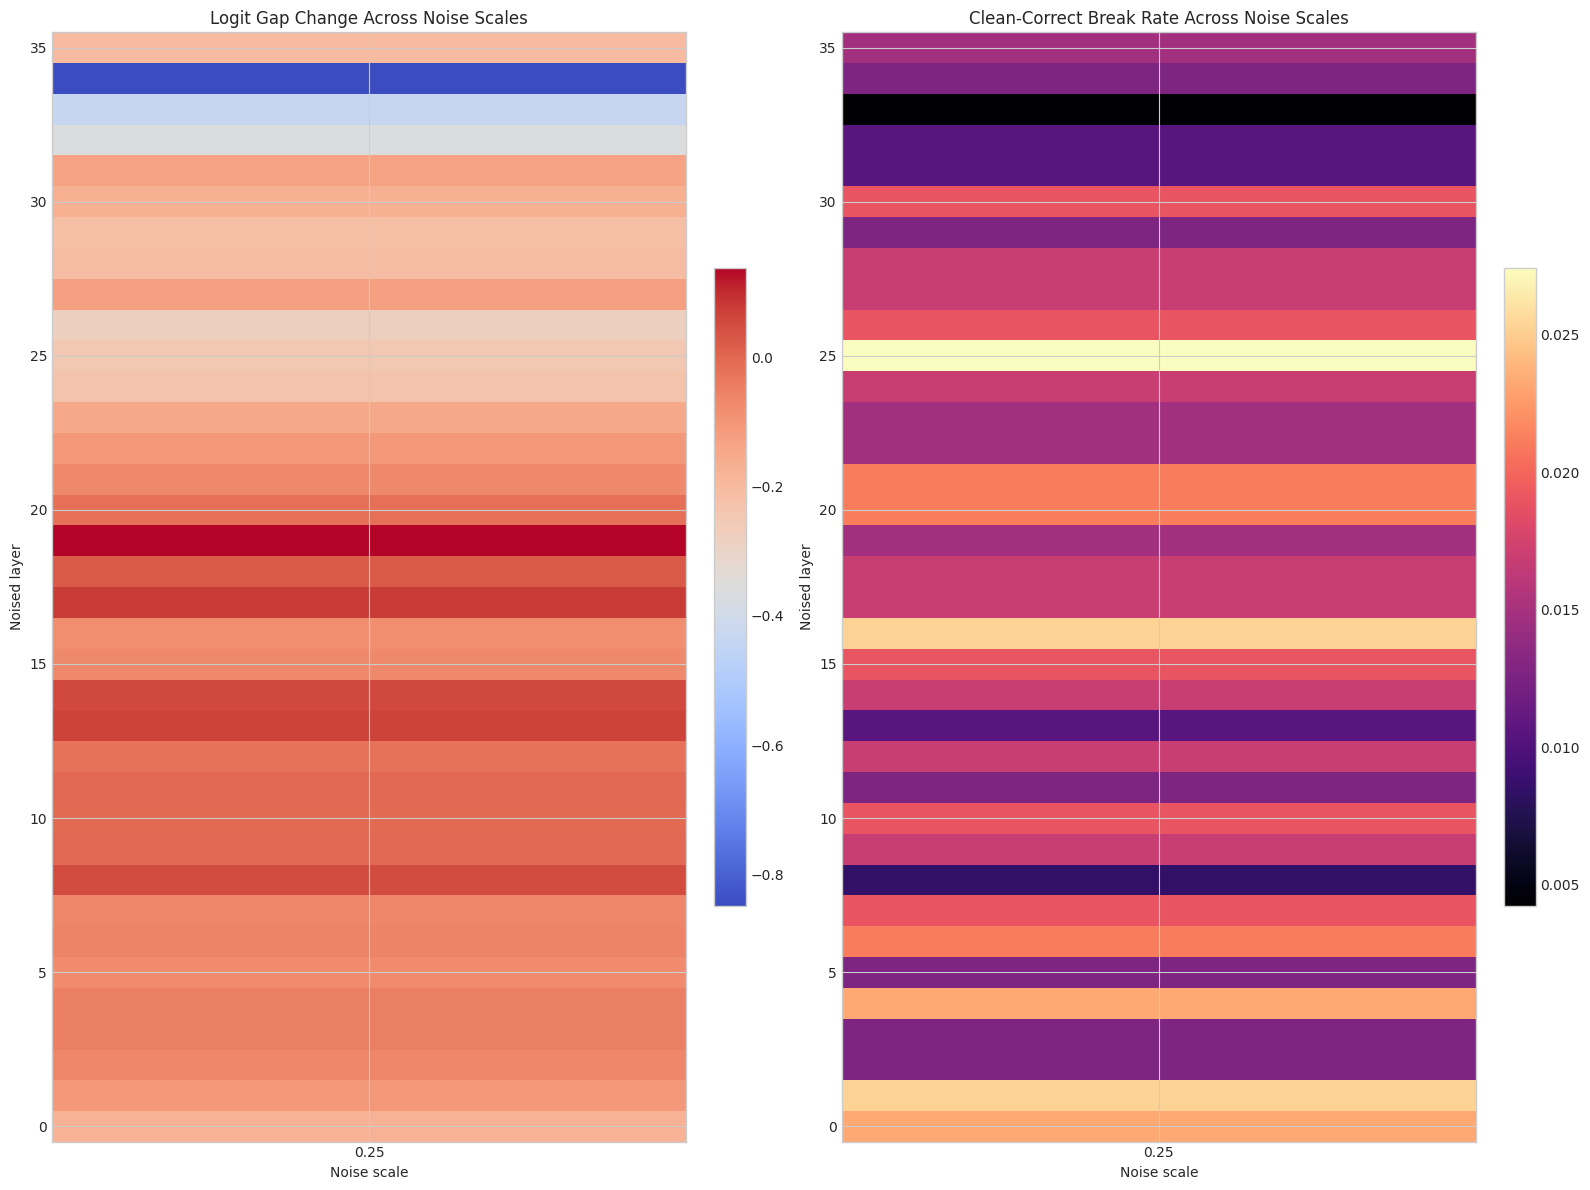

In [19]:
def pivot_dose_metric(metric_name):
    table = (
        dose_response_summary.pivot(index="layer_index_1based", columns="noise_scale", values=metric_name)
        .sort_index()
    )
    return table


dose_margin_delta = pivot_dose_metric("mean_delta_true_answer_vs_best_other_logit_gap")
dose_break_rate = pivot_dose_metric("clean_correct_break_rate")

fig, axes = plt.subplots(1, 2, figsize=(16, 12))

im0 = axes[0].imshow(dose_margin_delta.to_numpy(), aspect="auto", origin="lower", cmap="coolwarm")
axes[0].set_title("Logit Gap Change Across Noise Scales")
axes[0].set_xlabel("Noise scale")
axes[0].set_ylabel("Noised layer")
axes[0].set_xticks(np.arange(len(dose_margin_delta.columns)))
axes[0].set_xticklabels([str(x) for x in dose_margin_delta.columns])
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(dose_break_rate.to_numpy(), aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("Clean-Correct Break Rate Across Noise Scales")
axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Noised layer")
axes[1].set_xticks(np.arange(len(dose_break_rate.columns)))
axes[1].set_xticklabels([str(x) for x in dose_break_rate.columns])
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


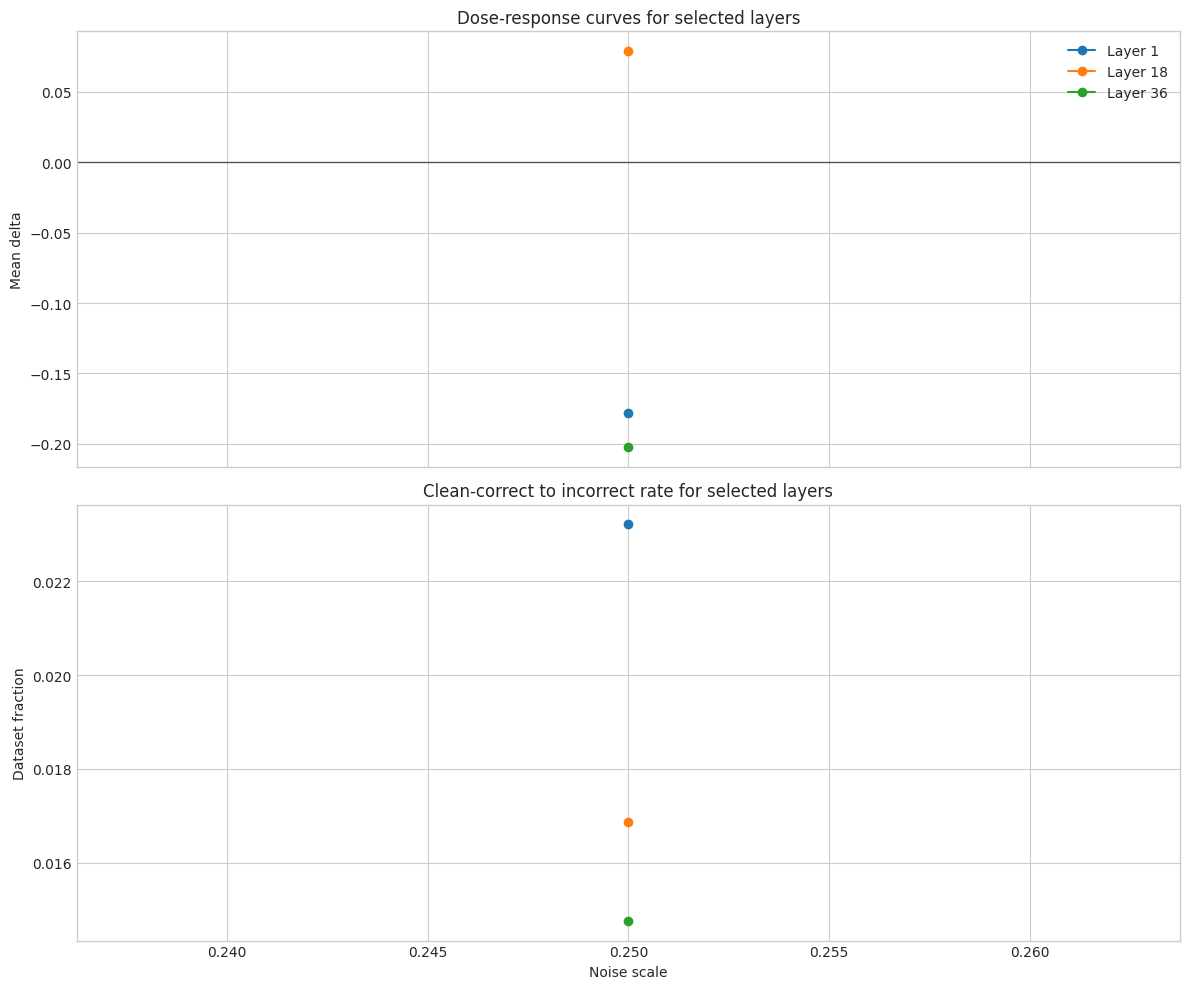

In [20]:
selected_layers = sorted({1, max(1, L // 2), L})
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

for layer_index_1based in selected_layers:
    part = dose_response_summary.loc[dose_response_summary["layer_index_1based"].eq(layer_index_1based)].sort_values("noise_scale")
    axes[0].plot(part["noise_scale"], part["mean_delta_true_answer_vs_best_other_logit_gap"], marker="o", label=f"Layer {layer_index_1based}")
    axes[1].plot(part["noise_scale"], part["clean_correct_break_rate"], marker="o", label=f"Layer {layer_index_1based}")

axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Dose-response curves for selected layers")
axes[0].legend()

axes[1].set_xlabel("Noise scale")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Clean-correct to incorrect rate for selected layers")

plt.tight_layout()
plt.show()


## Hypothesis-Driven Follow-Up

Targeted analysis of intervention outputs against descriptive layerwise signals.


### Descriptive Reference Curves

Clean layer-output reference curves:

- normalized answer-choice entropy
- answer-choice top1-top2 logit gap


In [21]:
def extract_descriptive_reference_curves(frame):
    rows = []

    for start in tqdm(range(0, len(frame), CLEAN_BATCH_SIZE), total=int(math.ceil(len(frame) / CLEAN_BATCH_SIZE)), desc="descriptive reference curves"):
        batch_df = frame.iloc[start:start + CLEAN_BATCH_SIZE].reset_index(drop=True)
        batch_cpu = encode_prompts(batch_df["text"], tok, MAX_SEQ_LEN)
        decision_pos = batch_cpu.pop("decision_pos")
        batch = {k: v.to(model.device) for k, v in batch_cpu.items()}
        decision_pos = decision_pos.to(model.device)

        with torch.no_grad():
            out = model(**batch, output_hidden_states=True, return_dict=True, use_cache=False)

        hidden_states = out.hidden_states
        bsz = len(batch_df)
        row_idx = torch.arange(bsz, device=decision_pos.device)

        entropy_blocks = []
        gap_blocks = []

        for li in range(L):
            hidden = hidden_states[li + 1][row_idx, decision_pos].float()
            readout = maybe_apply_final_norm_gpu(hidden, li)
            choice_logits = torch.matmul(readout, model.lm_head.weight[answer_ids_on_device].float().T)
            choice_probs = torch.softmax(choice_logits, dim=-1)
            choice_entropy = -(choice_probs * torch.log(torch.clamp(choice_probs, min=1e-12))).sum(dim=-1) / log_answer_choice_count
            sorted_logits = torch.sort(choice_logits, dim=-1, descending=True).values
            top1_top2_gap = sorted_logits[:, 0] - sorted_logits[:, 1]

            entropy_blocks.append(choice_entropy.detach().cpu().numpy().astype(np.float32))
            gap_blocks.append(top1_top2_gap.detach().cpu().numpy().astype(np.float32))

        entropy_matrix = np.stack(entropy_blocks, axis=1)
        gap_matrix = np.stack(gap_blocks, axis=1)

        for bi in range(bsz):
            rows.append(
                {
                    "example_id": batch_df.loc[bi, "example_id"],
                    "answer_choice_entropy_curve": entropy_matrix[bi].copy(),
                    "answer_choice_top1_top2_gap_curve": gap_matrix[bi].copy(),
                }
            )

    return pd.DataFrame(rows)


descriptive_df = extract_descriptive_reference_curves(eval_rows)
analysis_df = analysis_df.merge(descriptive_df, on="example_id", how="left", validate="one_to_one")

reference_entropy_curve = np.stack(analysis_df["answer_choice_entropy_curve"].to_list(), axis=0).mean(axis=0)
reference_gap_curve = np.stack(analysis_df["answer_choice_top1_top2_gap_curve"].to_list(), axis=0).mean(axis=0)

descriptive_layer_summary = pd.DataFrame(
    {
        "layer_index_1based": np.arange(1, L + 1),
        "mean_answer_choice_entropy": reference_entropy_curve,
        "mean_answer_choice_top1_top2_gap": reference_gap_curve,
    }
)

display(descriptive_layer_summary.head(10).round(4))


descriptive reference curves: 100%|██████████| 150/150 [00:09<00:00, 16.58it/s]


,layer_index_1based,mean_answer_choice_entropy,mean_answer_choice_top1_top2_gap
0,1,0.6420,0.6547
1,2,0.7587,0.1276
2,3,0.7511,0.1947
3,4,0.5008,1.5183
4,5,0.2431,3.1585
5,6,0.6637,1.1511
6,7,0.5192,1.0980
7,8,0.5749,0.8917
8,9,0.6134,0.5239
9,10,0.8731,0.5897


### Early-Middle-Late Aggregation


In [22]:
region_edges = np.linspace(0, L, 4, dtype=int)

def assign_layer_region(layer_index_1based):
    if layer_index_1based <= region_edges[1]:
        return "Early layers"
    if layer_index_1based <= region_edges[2]:
        return "Middle layers"
    return "Late layers"


layer_output_df["layer_region"] = layer_output_df["target_layer"].add(1).map(assign_layer_region)
region_summary_by_scale = intervention_summary(layer_output_df, ["noise_scale", "layer_region"])
region_summary = aggregate_summary_across_noise_scales(region_summary_by_scale, ["layer_region"])
region_summary["layer_region"] = pd.Categorical(
    region_summary["layer_region"],
    categories=["Early layers", "Middle layers", "Late layers"],
    ordered=True,
)
region_summary = region_summary.sort_values("layer_region").reset_index(drop=True)

display(region_summary_by_scale.round(4))
display(region_summary.round(4))


,noise_scale,layer_region,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
0,0.25,Early layers,-0.0512,0.9676,0.7887,0.0172,0.9828
1,0.25,Late layers,-0.2886,0.9711,0.7893,0.0151,0.9849
2,0.25,Middle layers,-0.0133,0.9628,0.7910,0.0174,0.9826


,layer_region,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,noised_accuracy_std,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean,noised_accuracy_on_clean_correct_std
0,Early layers,-0.0512,0.0,0.9676,0.0,0.7887,0.0,0.0172,0.0,0.9828,0.0
1,Middle layers,-0.0133,0.0,0.9628,0.0,0.7910,0.0,0.0174,0.0,0.9826,0.0
2,Late layers,-0.2886,0.0,0.9711,0.0,0.7893,0.0,0.0151,0.0,0.9849,0.0


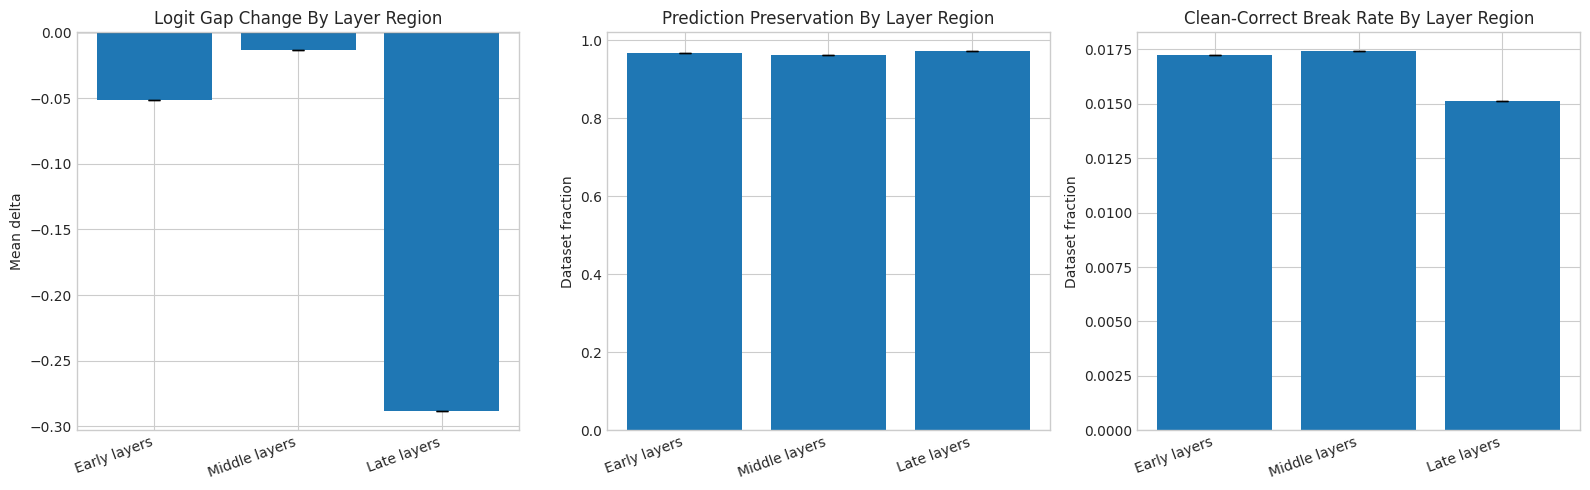

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x = np.arange(len(region_summary))
labels = region_summary["layer_region"].astype(str).tolist()

axes[0].bar(x, region_summary["mean_delta_true_answer_vs_best_other_logit_gap_mean"], yerr=region_summary["mean_delta_true_answer_vs_best_other_logit_gap_std"], capsize=4)
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=20, ha="right")
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Logit Gap Change By Layer Region")

axes[1].bar(x, region_summary["prediction_preservation_rate_mean"], yerr=region_summary["prediction_preservation_rate_std"], capsize=4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=20, ha="right")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Prediction Preservation By Layer Region")

axes[2].bar(x, region_summary["clean_correct_break_rate_mean"], yerr=region_summary["clean_correct_break_rate_std"], capsize=4)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=20, ha="right")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-Correct Break Rate By Layer Region")

plt.tight_layout()
plt.show()


### Stabilization-Window Comparison


In [24]:
window_size = 4
stabilization_start = min(max(1, 25), max(1, L - window_size + 1))
stabilization_layers = set(range(stabilization_start, min(L, stabilization_start + window_size - 1) + 1))

middle_start = max(1, (L // 2) - (window_size // 2) + 1)
middle_start = min(middle_start, max(1, L - window_size + 1))
middle_layers = set(range(middle_start, min(L, middle_start + window_size - 1) + 1))

early_layers = set(range(1, min(L, window_size) + 1))
late_start = max(1, L - window_size + 1)
late_layers = set(range(late_start, L + 1))

def assign_window_label(layer_index_1based):
    if layer_index_1based in stabilization_layers:
        return "Stabilization window"
    if layer_index_1based in early_layers:
        return "Early control window"
    if layer_index_1based in middle_layers:
        return "Middle control window"
    if layer_index_1based in late_layers:
        return "Late control window"
    return None


window_df = layer_output_df.copy()
window_df["window_label"] = window_df["target_layer"].add(1).map(assign_window_label)
window_df = window_df.loc[window_df["window_label"].notna()].copy()

window_summary_by_scale = intervention_summary(window_df, ["noise_scale", "window_label"])
window_summary = aggregate_summary_across_noise_scales(window_summary_by_scale, ["window_label"])
window_summary["window_label"] = pd.Categorical(
    window_summary["window_label"],
    categories=[
        "Early control window",
        "Middle control window",
        "Stabilization window",
        "Late control window",
    ],
    ordered=True,
)
window_summary = window_summary.sort_values("window_label").reset_index(drop=True)

display(window_summary_by_scale.round(4))
display(window_summary.round(4))


,noise_scale,window_label,mean_delta_true_answer_vs_best_other_logit_gap,prediction_preservation_rate,noised_accuracy,clean_correct_break_rate,noised_accuracy_on_clean_correct
0,0.25,Early control window,-0.0999,0.9646,0.7887,0.0185,0.9815
1,0.25,Late control window,-0.4623,0.9783,0.7912,0.0105,0.9895
2,0.25,Middle control window,0.0395,0.9625,0.7896,0.0185,0.9815
3,0.25,Stabilization window,-0.2218,0.9625,0.7875,0.0200,0.9800


,window_label,mean_delta_true_answer_vs_best_other_logit_gap_mean,mean_delta_true_answer_vs_best_other_logit_gap_std,prediction_preservation_rate_mean,prediction_preservation_rate_std,noised_accuracy_mean,noised_accuracy_std,clean_correct_break_rate_mean,clean_correct_break_rate_std,noised_accuracy_on_clean_correct_mean,noised_accuracy_on_clean_correct_std
0,Early control window,-0.0999,0.0,0.9646,0.0,0.7887,0.0,0.0185,0.0,0.9815,0.0
1,Middle control window,0.0395,0.0,0.9625,0.0,0.7896,0.0,0.0185,0.0,0.9815,0.0
2,Stabilization window,-0.2218,0.0,0.9625,0.0,0.7875,0.0,0.0200,0.0,0.9800,0.0
3,Late control window,-0.4623,0.0,0.9783,0.0,0.7912,0.0,0.0105,0.0,0.9895,0.0


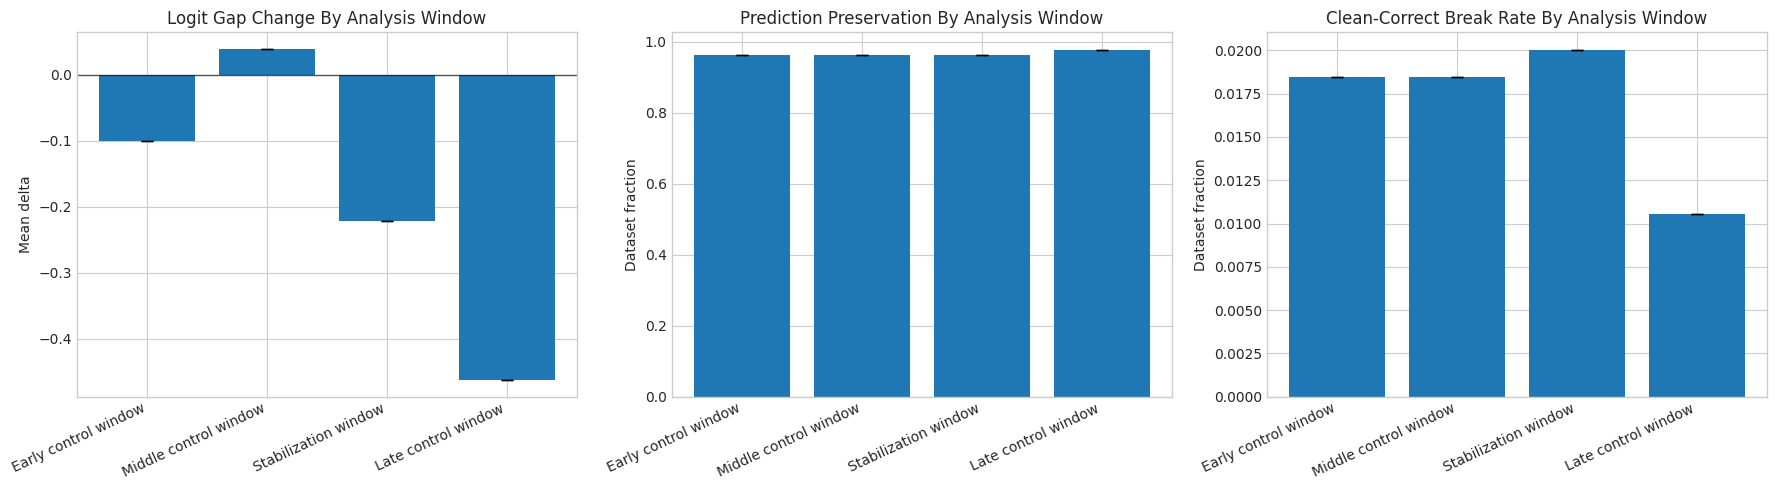

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
x = np.arange(len(window_summary))
labels = window_summary["window_label"].astype(str).tolist()

axes[0].bar(x, window_summary["mean_delta_true_answer_vs_best_other_logit_gap_mean"], yerr=window_summary["mean_delta_true_answer_vs_best_other_logit_gap_std"], capsize=4)
axes[0].axhline(0.0, color="black", linewidth=1, alpha=0.6)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=25, ha="right")
axes[0].set_ylabel("Mean delta")
axes[0].set_title("Logit Gap Change By Analysis Window")

axes[1].bar(x, window_summary["prediction_preservation_rate_mean"], yerr=window_summary["prediction_preservation_rate_std"], capsize=4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].set_ylabel("Dataset fraction")
axes[1].set_title("Prediction Preservation By Analysis Window")

axes[2].bar(x, window_summary["clean_correct_break_rate_mean"], yerr=window_summary["clean_correct_break_rate_std"], capsize=4)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels, rotation=25, ha="right")
axes[2].set_ylabel("Dataset fraction")
axes[2].set_title("Clean-Correct Break Rate By Analysis Window")

plt.tight_layout()
plt.show()


### Descriptive-Versus-Causal Comparison For Entropy


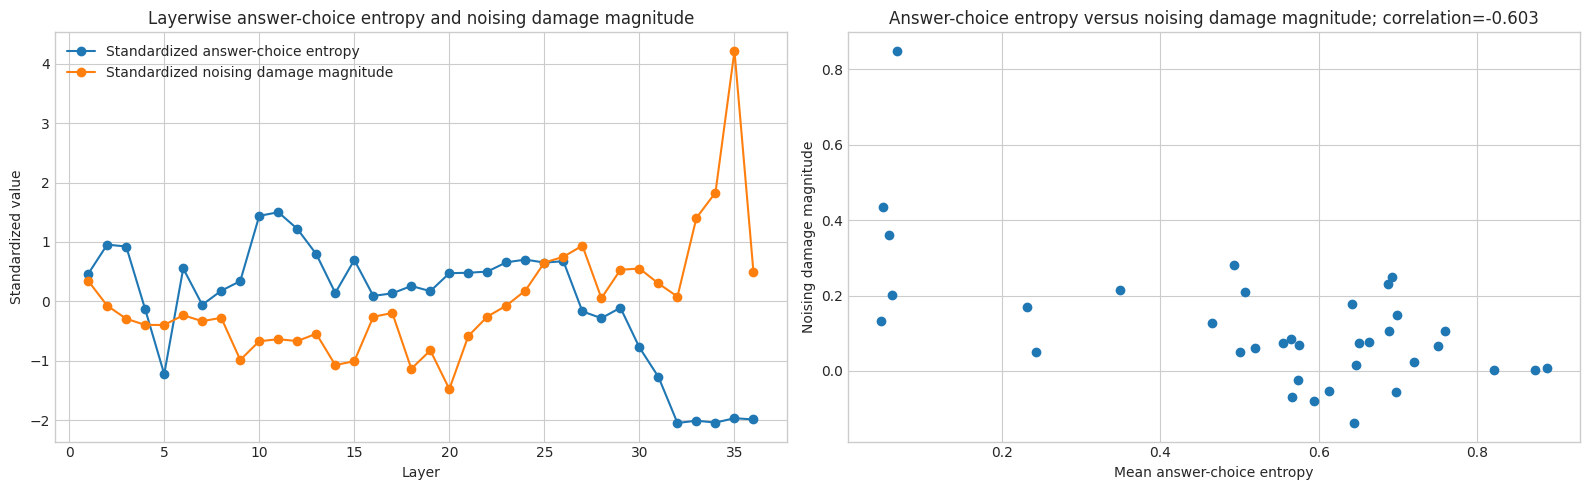

,metric_pair,correlation
0,Answer-choice entropy vs noising damage magnitude,-0.6030
1,Answer-choice entropy vs clean-correct break rate,0.3636


In [26]:
comparison_df = layer_output_summary.merge(descriptive_layer_summary, on="layer_index_1based", how="inner", validate="one_to_one")
comparison_df["damage_magnitude"] = -comparison_df["mean_delta_true_answer_vs_best_other_logit_gap_mean"]

entropy_overlay_damage = standardize_series(comparison_df["damage_magnitude"])
entropy_overlay_curve = standardize_series(comparison_df["mean_answer_choice_entropy"])
entropy_damage_corr = float(np.corrcoef(comparison_df["mean_answer_choice_entropy"], comparison_df["damage_magnitude"])[0, 1])
entropy_break_corr = float(np.corrcoef(comparison_df["mean_answer_choice_entropy"], comparison_df["clean_correct_break_rate_mean"])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(comparison_df["layer_index_1based"], entropy_overlay_curve, marker="o", label="Standardized answer-choice entropy")
axes[0].plot(comparison_df["layer_index_1based"], entropy_overlay_damage, marker="o", label="Standardized noising damage magnitude")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Standardized value")
axes[0].set_title("Layerwise answer-choice entropy and noising damage magnitude")
axes[0].legend()

axes[1].scatter(comparison_df["mean_answer_choice_entropy"], comparison_df["damage_magnitude"])
axes[1].set_xlabel("Mean answer-choice entropy")
axes[1].set_ylabel("Noising damage magnitude")
axes[1].set_title(f"Answer-choice entropy versus noising damage magnitude; correlation={entropy_damage_corr:.3f}")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric_pair": [
                "Answer-choice entropy vs noising damage magnitude",
                "Answer-choice entropy vs clean-correct break rate",
            ],
            "correlation": [
                entropy_damage_corr,
                entropy_break_corr,
            ],
        }
    ).round(4)
)


### Descriptive-Versus-Causal Comparison For Logit Gap


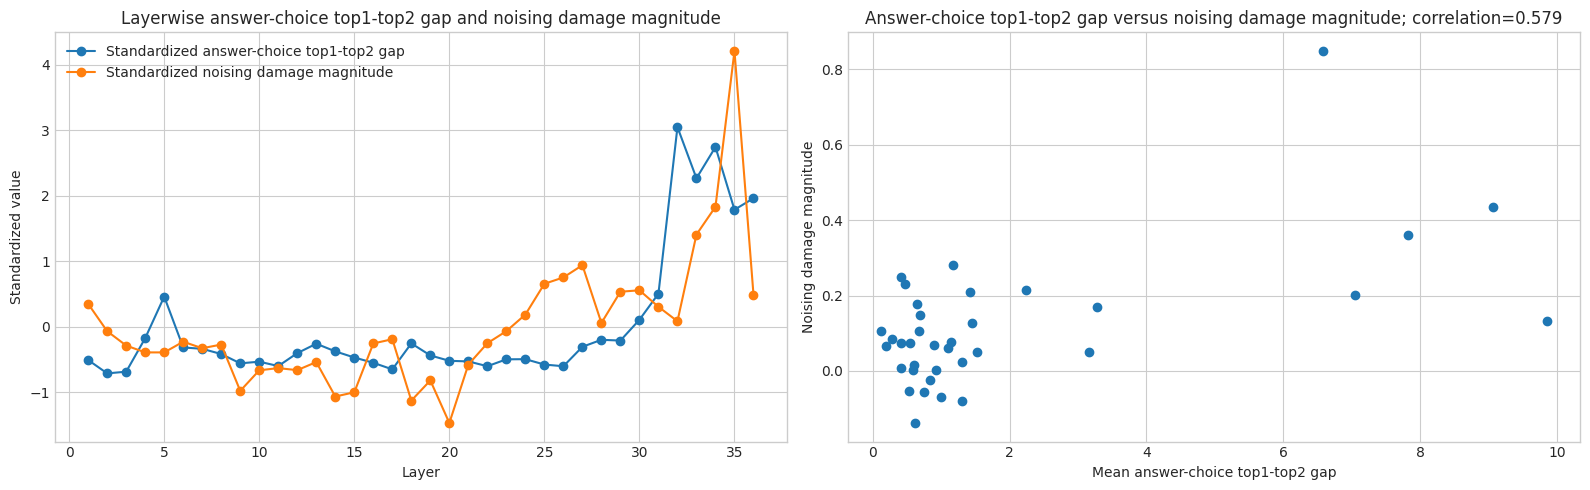

,metric_pair,correlation
0,Answer-choice top1-top2 gap vs noising damage ...,0.5790
1,Answer-choice top1-top2 gap vs clean-correct b...,-0.5096


In [27]:
gap_overlay_damage = standardize_series(comparison_df["damage_magnitude"])
gap_overlay_curve = standardize_series(comparison_df["mean_answer_choice_top1_top2_gap"])
gap_damage_corr = float(np.corrcoef(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["damage_magnitude"])[0, 1])
gap_break_corr = float(np.corrcoef(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["clean_correct_break_rate_mean"])[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(comparison_df["layer_index_1based"], gap_overlay_curve, marker="o", label="Standardized answer-choice top1-top2 gap")
axes[0].plot(comparison_df["layer_index_1based"], gap_overlay_damage, marker="o", label="Standardized noising damage magnitude")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Standardized value")
axes[0].set_title("Layerwise answer-choice top1-top2 gap and noising damage magnitude")
axes[0].legend()

axes[1].scatter(comparison_df["mean_answer_choice_top1_top2_gap"], comparison_df["damage_magnitude"])
axes[1].set_xlabel("Mean answer-choice top1-top2 gap")
axes[1].set_ylabel("Noising damage magnitude")
axes[1].set_title(f"Answer-choice top1-top2 gap versus noising damage magnitude; correlation={gap_damage_corr:.3f}")

plt.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "metric_pair": [
                "Answer-choice top1-top2 gap vs noising damage magnitude",
                "Answer-choice top1-top2 gap vs clean-correct break rate",
            ],
            "correlation": [
                gap_damage_corr,
                gap_break_corr,
            ],
        }
    ).round(4)
)
